# **AI‑Driven Churn Prediction for Personalized Retention in E‑Commerce**

The Chief Marketing Officer (CMO) of a leading retail e-commerce platform has   raised concerns about a *growing rate of customer attrition, negatively impacting average order value and overall customer lifetime value (CLV)*. To counter this trend, the CMO has tasked the Data & AI team with developing a predictive model capable of identifying customers who are at high risk of churning.
The insights generated will be used to inform proactive retention strategies such as personalized offers and targeted communications, aiming to boost loyalty and profitability. The executive team considers this project a key step toward enhancing customer retention, improving marketing effectiveness, and sustaining revenue growth.

### **1. Import Libraries**

In [61]:
%pip install numpy pandas matplotlib seaborn scikit-learn xgboost catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, silhouette_score, recall_score, precision_score, accuracy_score, roc_curve
from hyperopt import STATUS_OK, Trials, fmin, tpe, hp
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import shap

### **2. Load the dataset**

In [62]:
# Install openpyxl for reading Excel files
%pip install openpyxl

# Load the dataset from an Excel file
df = pd.read_excel("data.xlsx")
df.head(10)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001.0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002.0,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003.0,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004.0,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005.0,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006.0,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007.0,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008.0,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009.0,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010.0,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


In [63]:
df.info() # Display basic information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5628 non-null   float64
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5628 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [64]:
df.shape

(5630, 20)

In [65]:
df.nunique()  # Count unique values in each column


,0
CustomerID,5628
Churn,2
Tenure,36
PreferredLoginDevice,4
CityTier,3
WarehouseToHome,34
PreferredPaymentMode,7
Gender,2
HourSpendOnApp,6
NumberOfDeviceRegistered,6


In [66]:
##Coloumn Transformation

# int columns to convert to string
int_cols = ['CityTier', 'NumberOfAddress', 'Complain', 'SatisfactionScore', 'NumberOfDeviceRegistered','Churn'] # Columns to be transformed from int to string

# Transform selected columns: int -> string
for col in int_cols:
	df[col] = pd.to_numeric(df[col], errors='coerce').dropna().astype(str)

# Transform selected columns: float -> int -> string (handle NaNs safely)
feature_cols = [ 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount']

for col in feature_cols:
	# Convert to float, then to int (ignoring NaNs), then to string
	df[col] = pd.to_numeric(df[col], errors='coerce').dropna().astype(int).astype(str)

In [67]:
df.info()  # Check the data types after transformation

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5628 non-null   float64
 1   Churn                        5630 non-null   object 
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   object 
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5628 non-null   object 
 8   HourSpendOnApp               5375 non-null   object 
 9   NumberOfDeviceRegistered     5630 non-null   object 
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   object 
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [68]:
df_raw = df.copy()

In [69]:
# break variables into categorical and numerical

categorical_cols = (df_raw.dtypes[df_raw.dtypes == 'object'].index)
numerical_cols = df_raw.dtypes[df_raw.dtypes != 'object'].index.drop('CustomerID')

In [70]:
# Check unique values of each column in the dataset using a for loop
for column in categorical_cols:
        print("Column: {} - Unique Values: {}".format(column, df_raw[column].unique()))
        print("="*80)

Column: Churn - Unique Values: ['1' '0']
Column: PreferredLoginDevice - Unique Values: ['Mobile Phone' 'Phone' 'Computer' 'N.A.']
Column: CityTier - Unique Values: ['3' '1' '2']
Column: PreferredPaymentMode - Unique Values: ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
Column: Gender - Unique Values: ['Female' 'Male' nan]
Column: HourSpendOnApp - Unique Values: ['3' '2' nan '1' '0' '4' '5']
Column: NumberOfDeviceRegistered - Unique Values: ['3' '4' '5' '2' '1' '6']
Column: PreferedOrderCat - Unique Values: ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
Column: SatisfactionScore - Unique Values: ['2' '3' '5' '4' '1']
Column: MaritalStatus - Unique Values: ['Single' 'Divorced' 'Married' 'Widow']
Column: NumberOfAddress - Unique Values: ['9' '7' '6' '8' '3' '2' '4' '10' '1' '5' '19' '21' '11' '20' '22']
Column: Complain - Unique Values: ['1' '0']
Column: OrderAmountHikeFromlastYear - Unique Values: ['11' '15' '14' '23' '22' '16' '

### **3.Explorative Data Analysis(EDA)**

**Categorical variables**

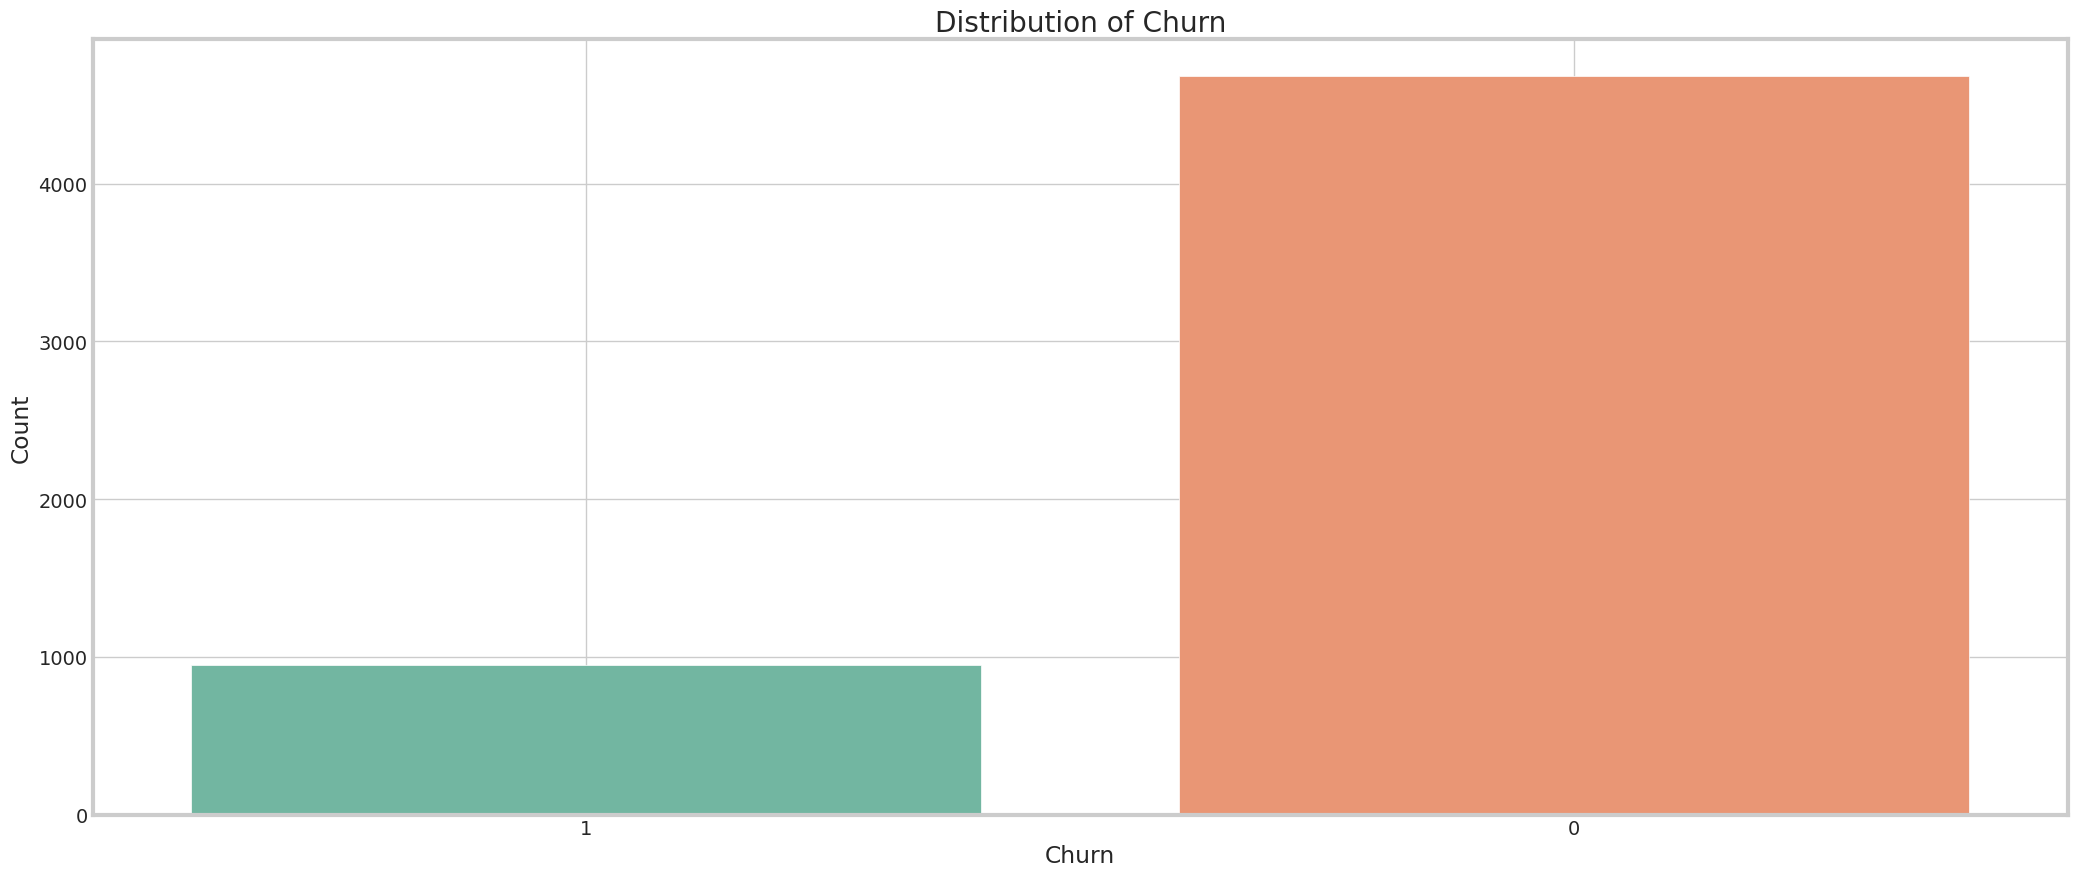

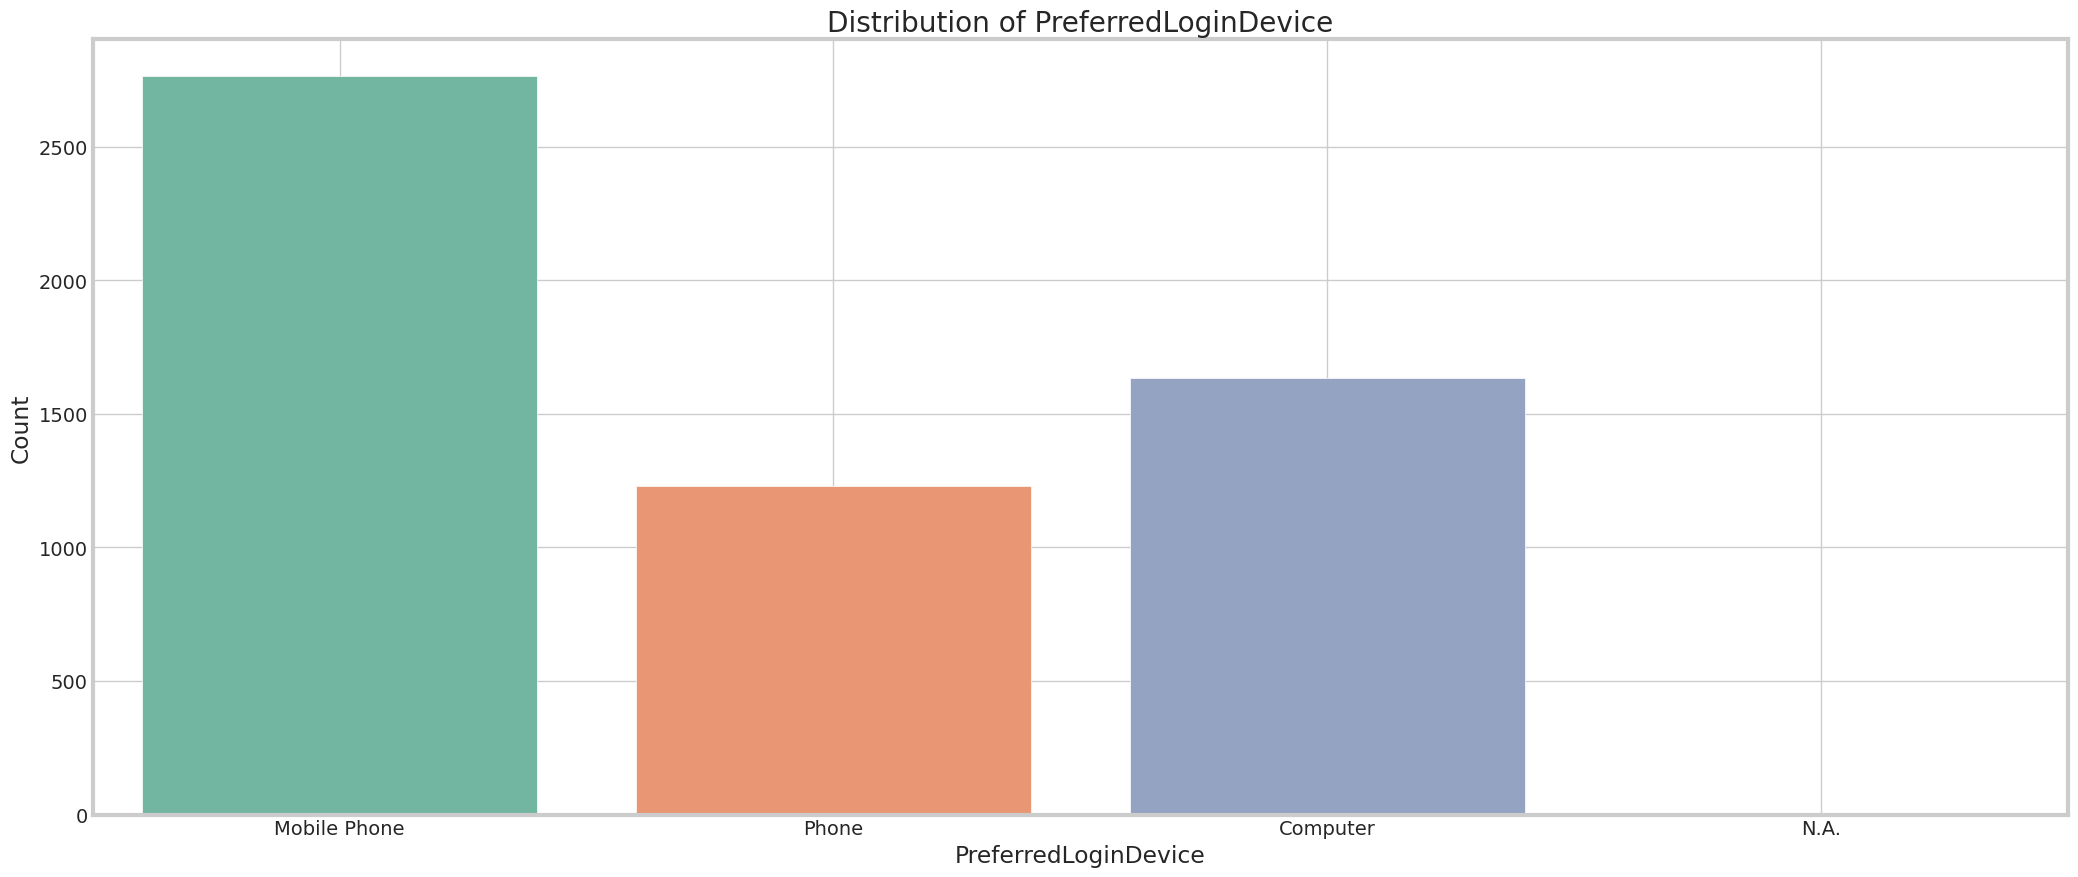

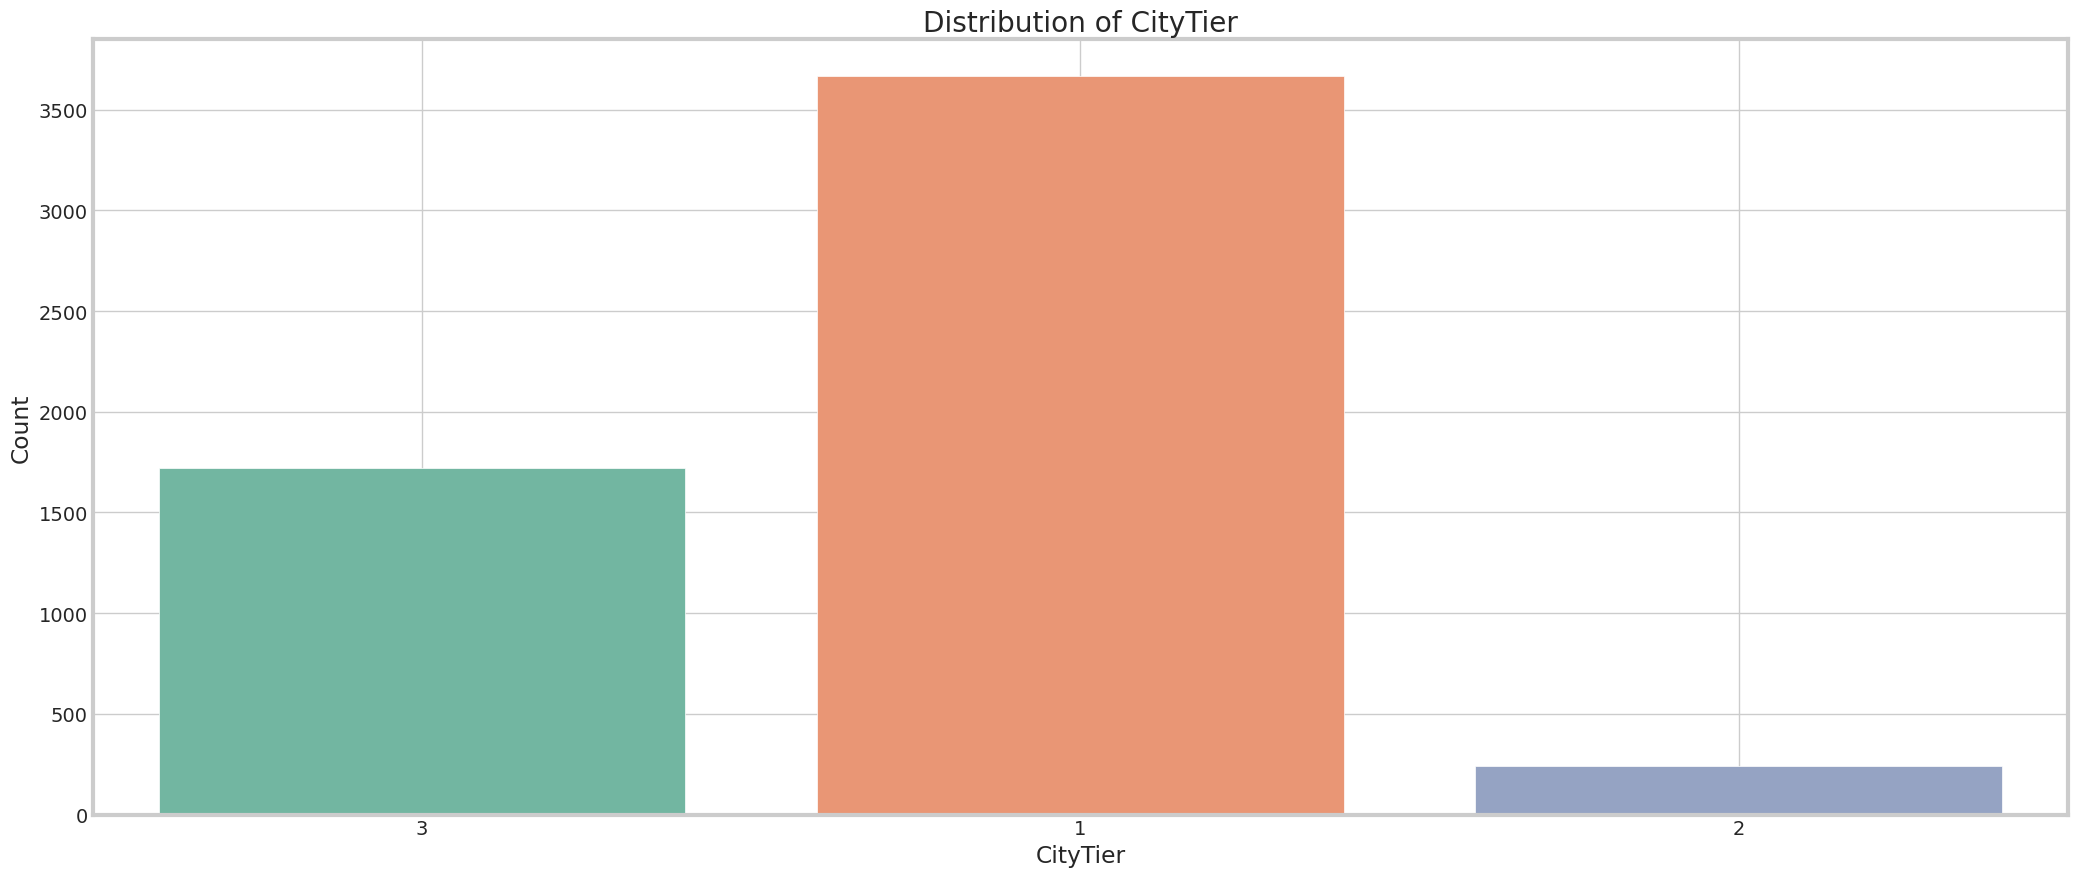

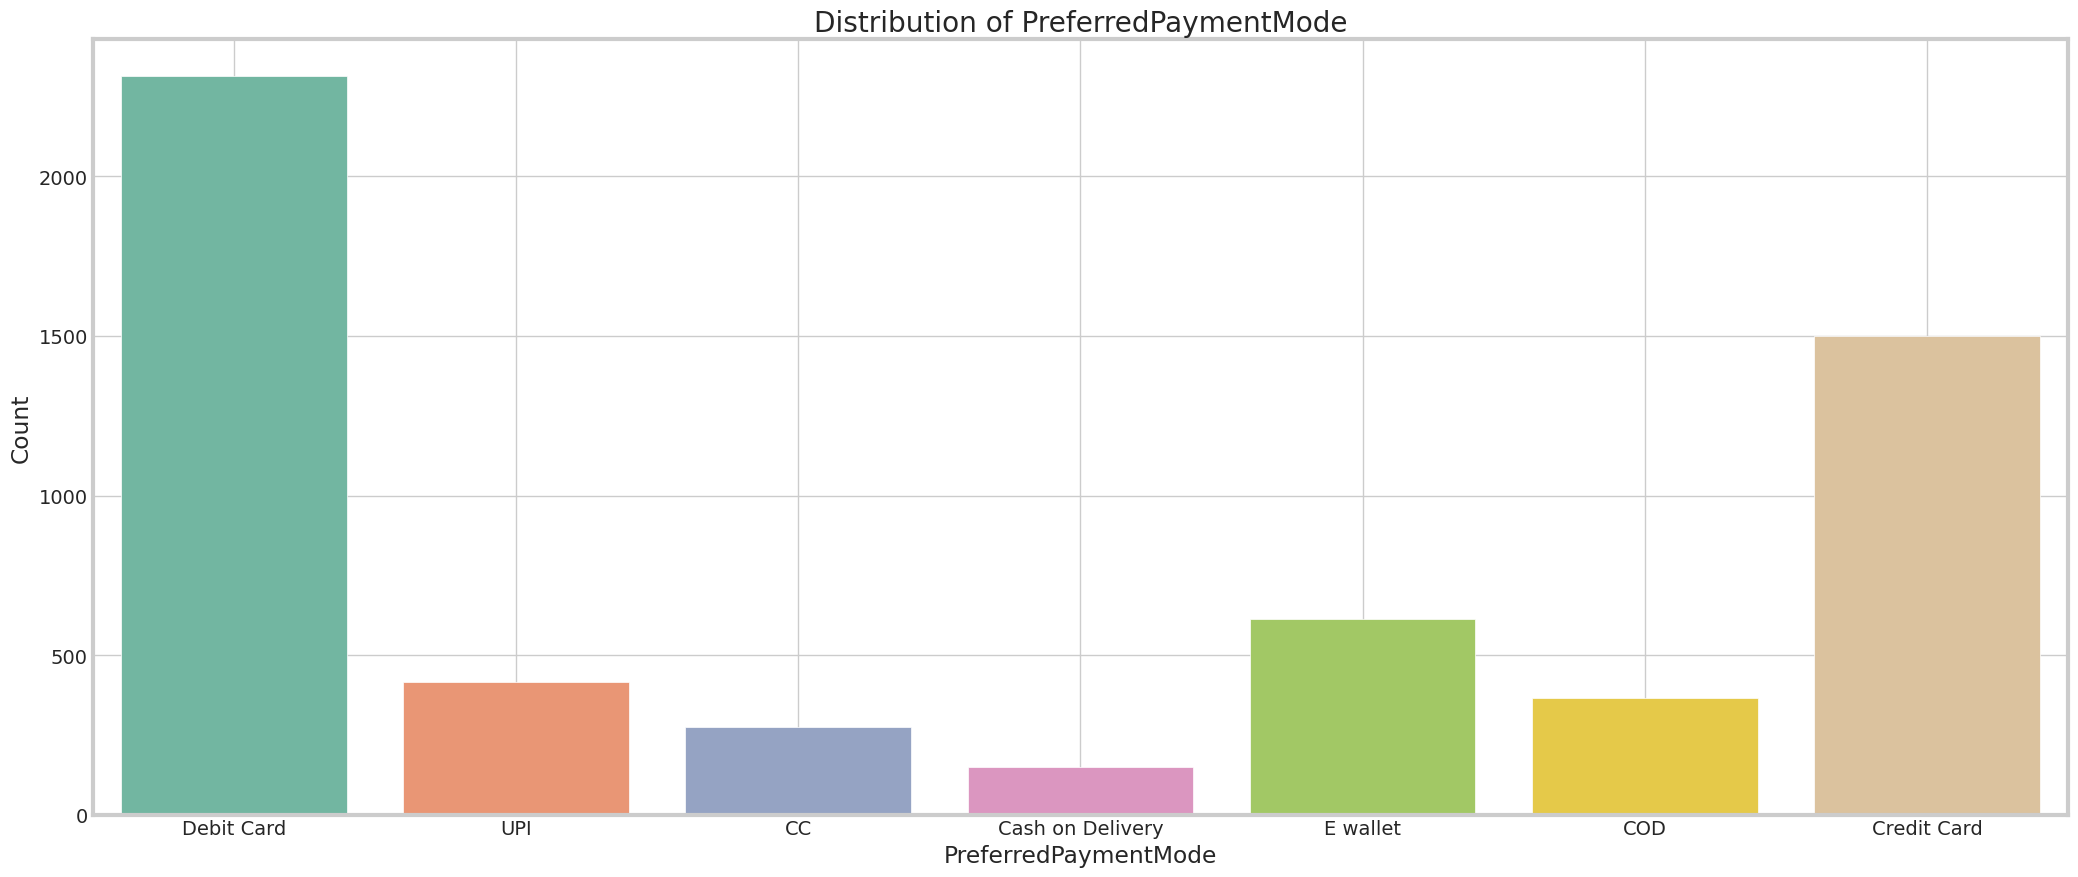

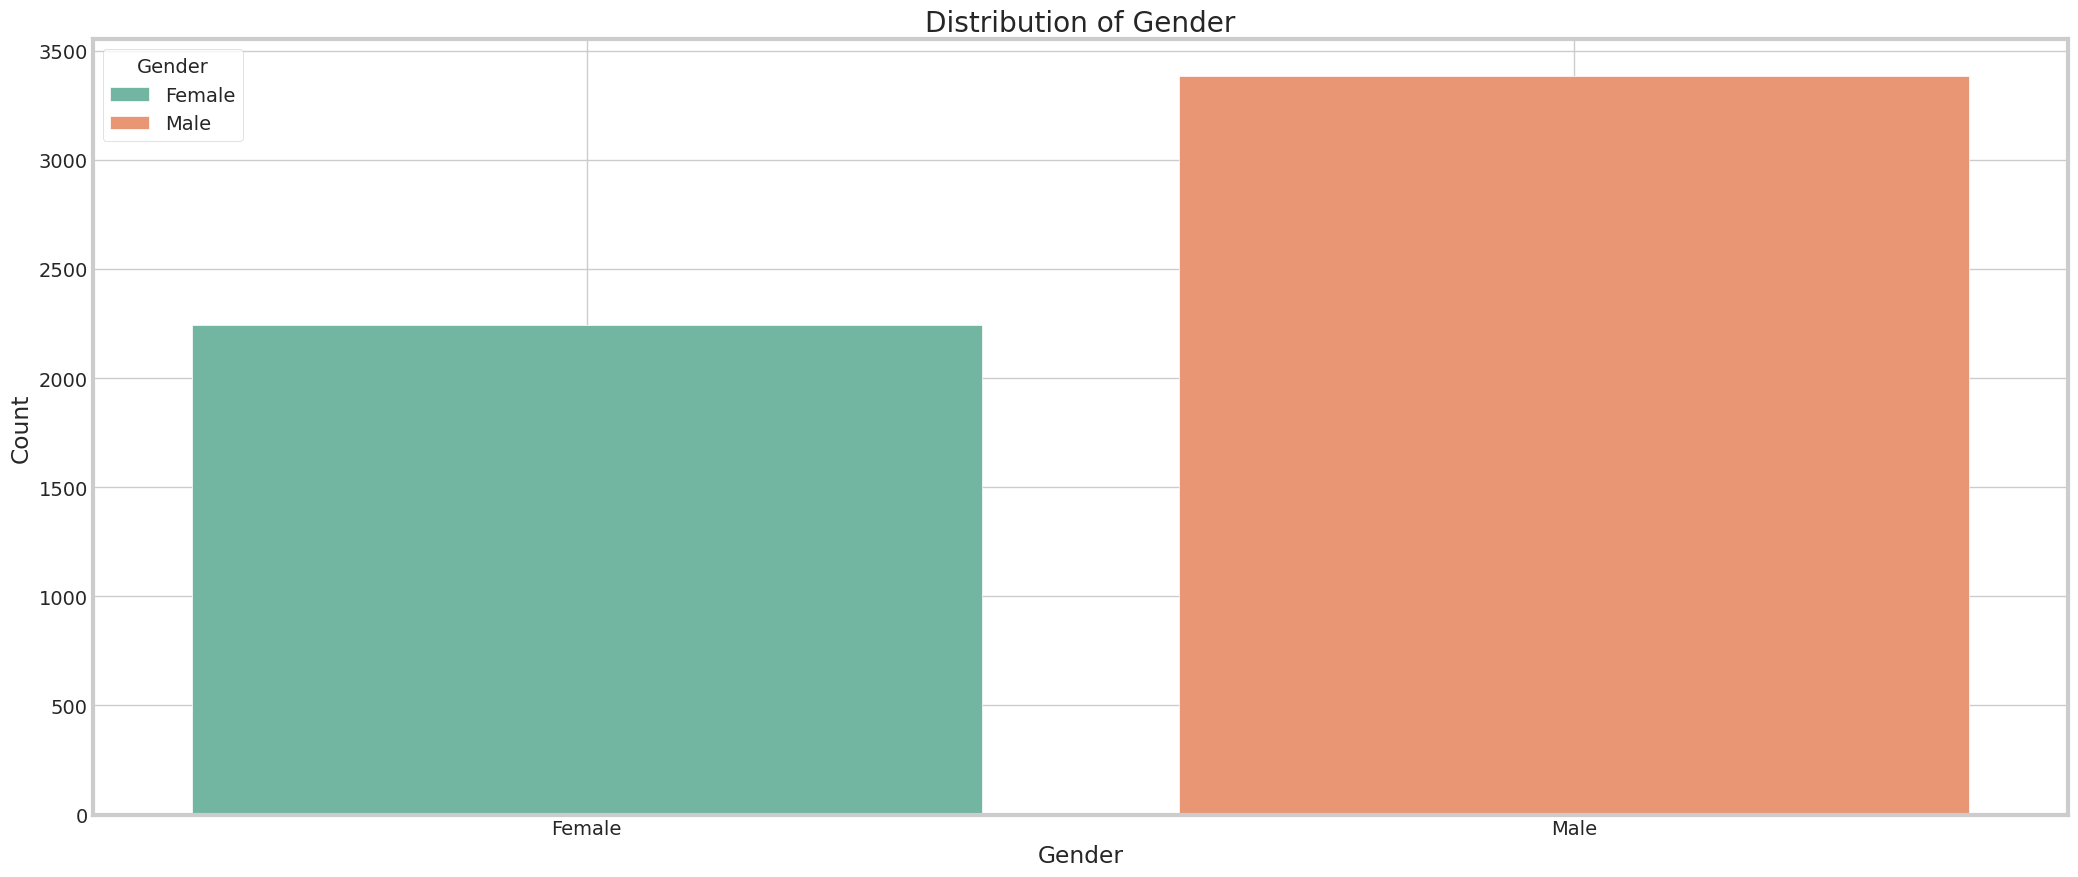

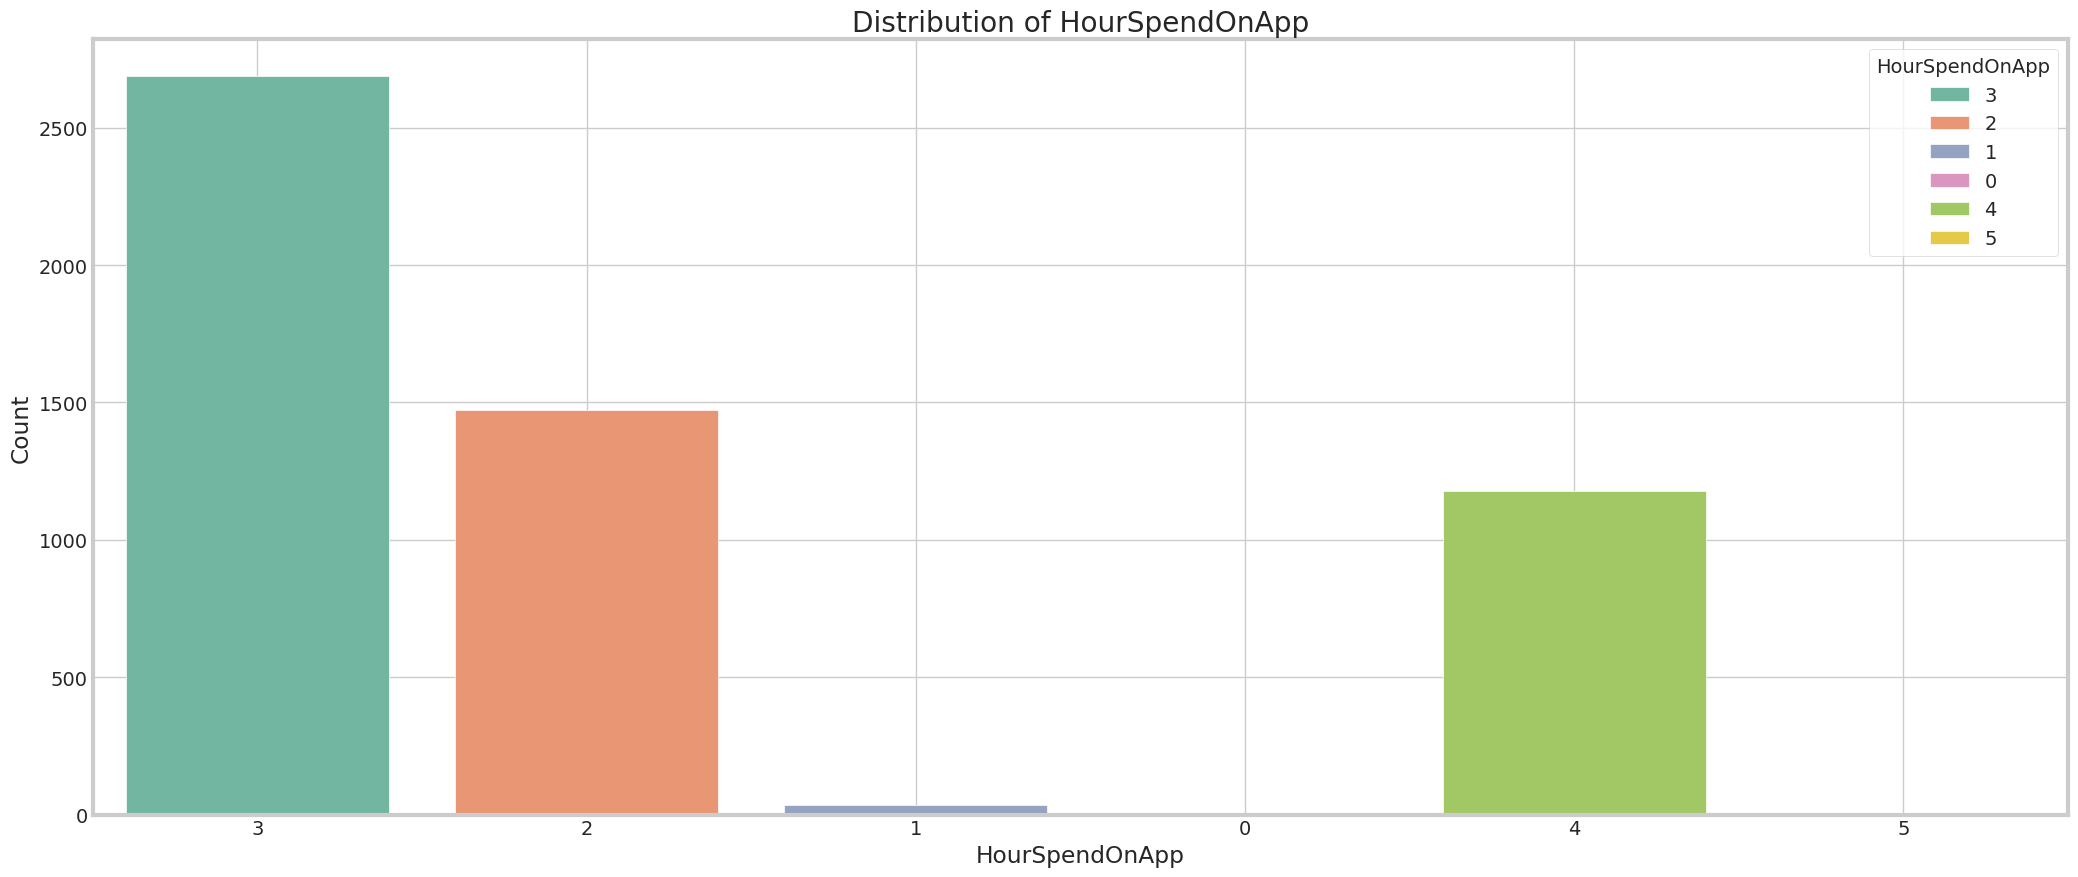

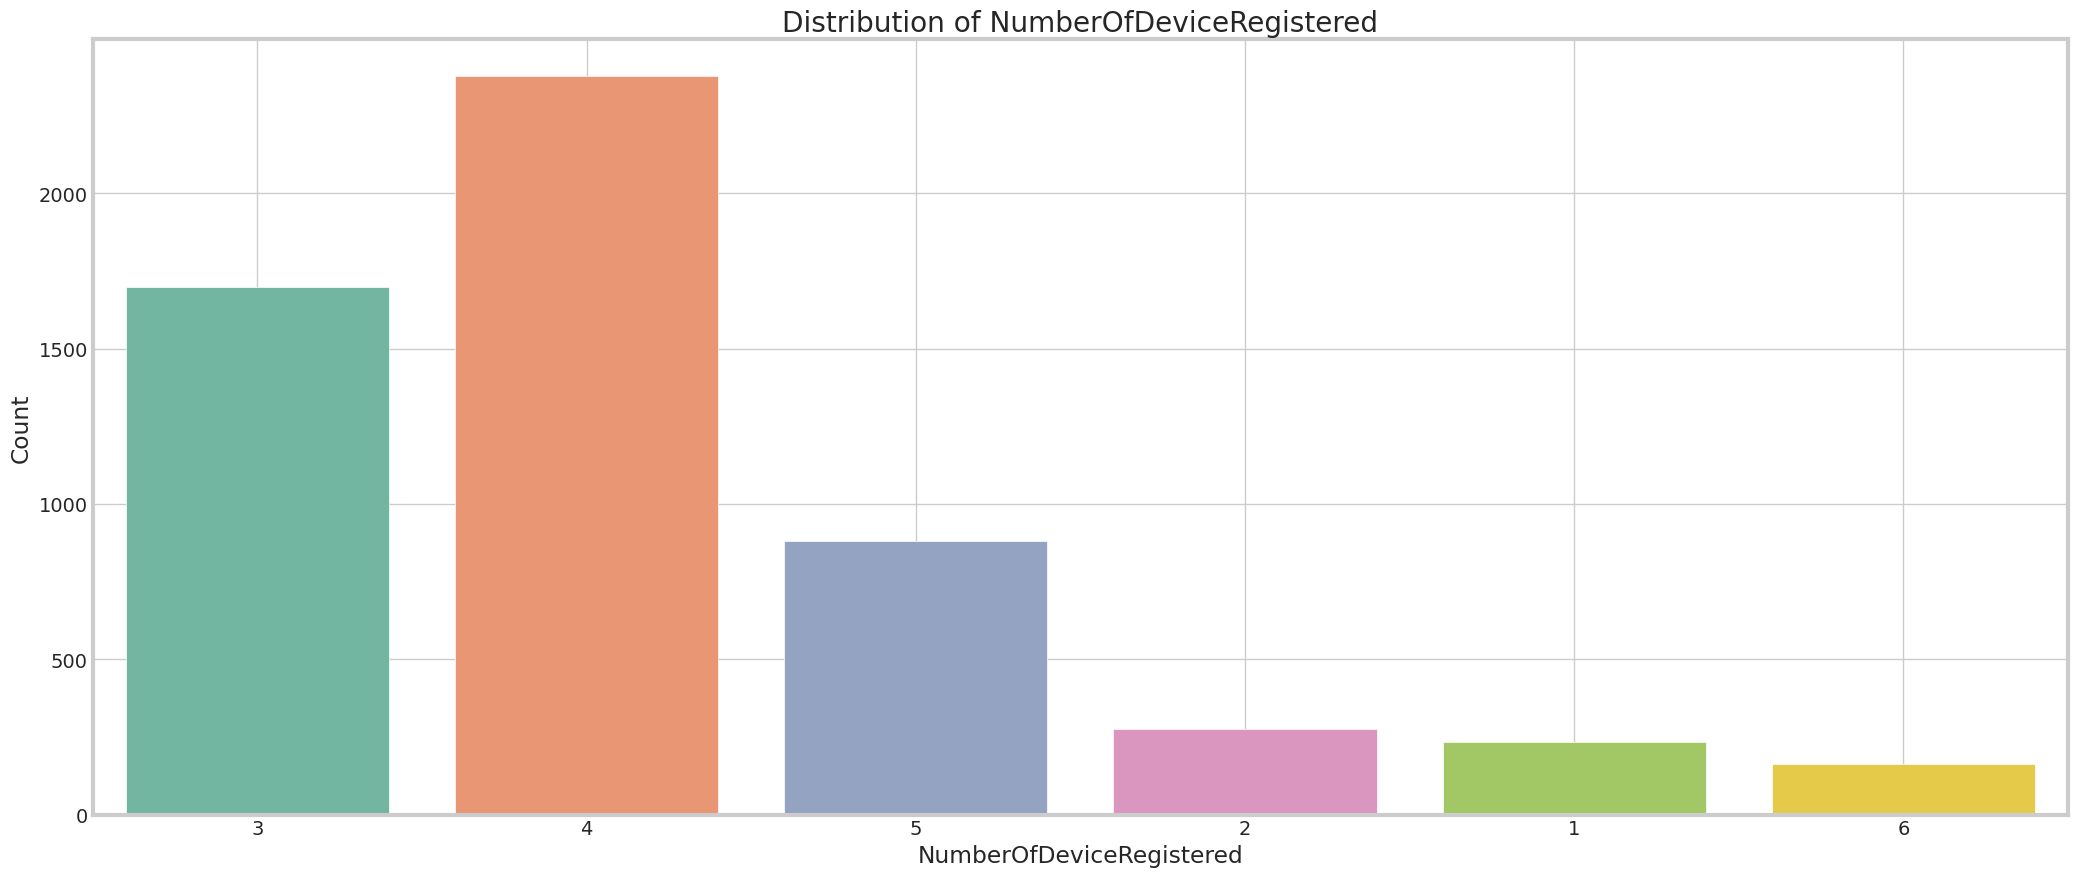

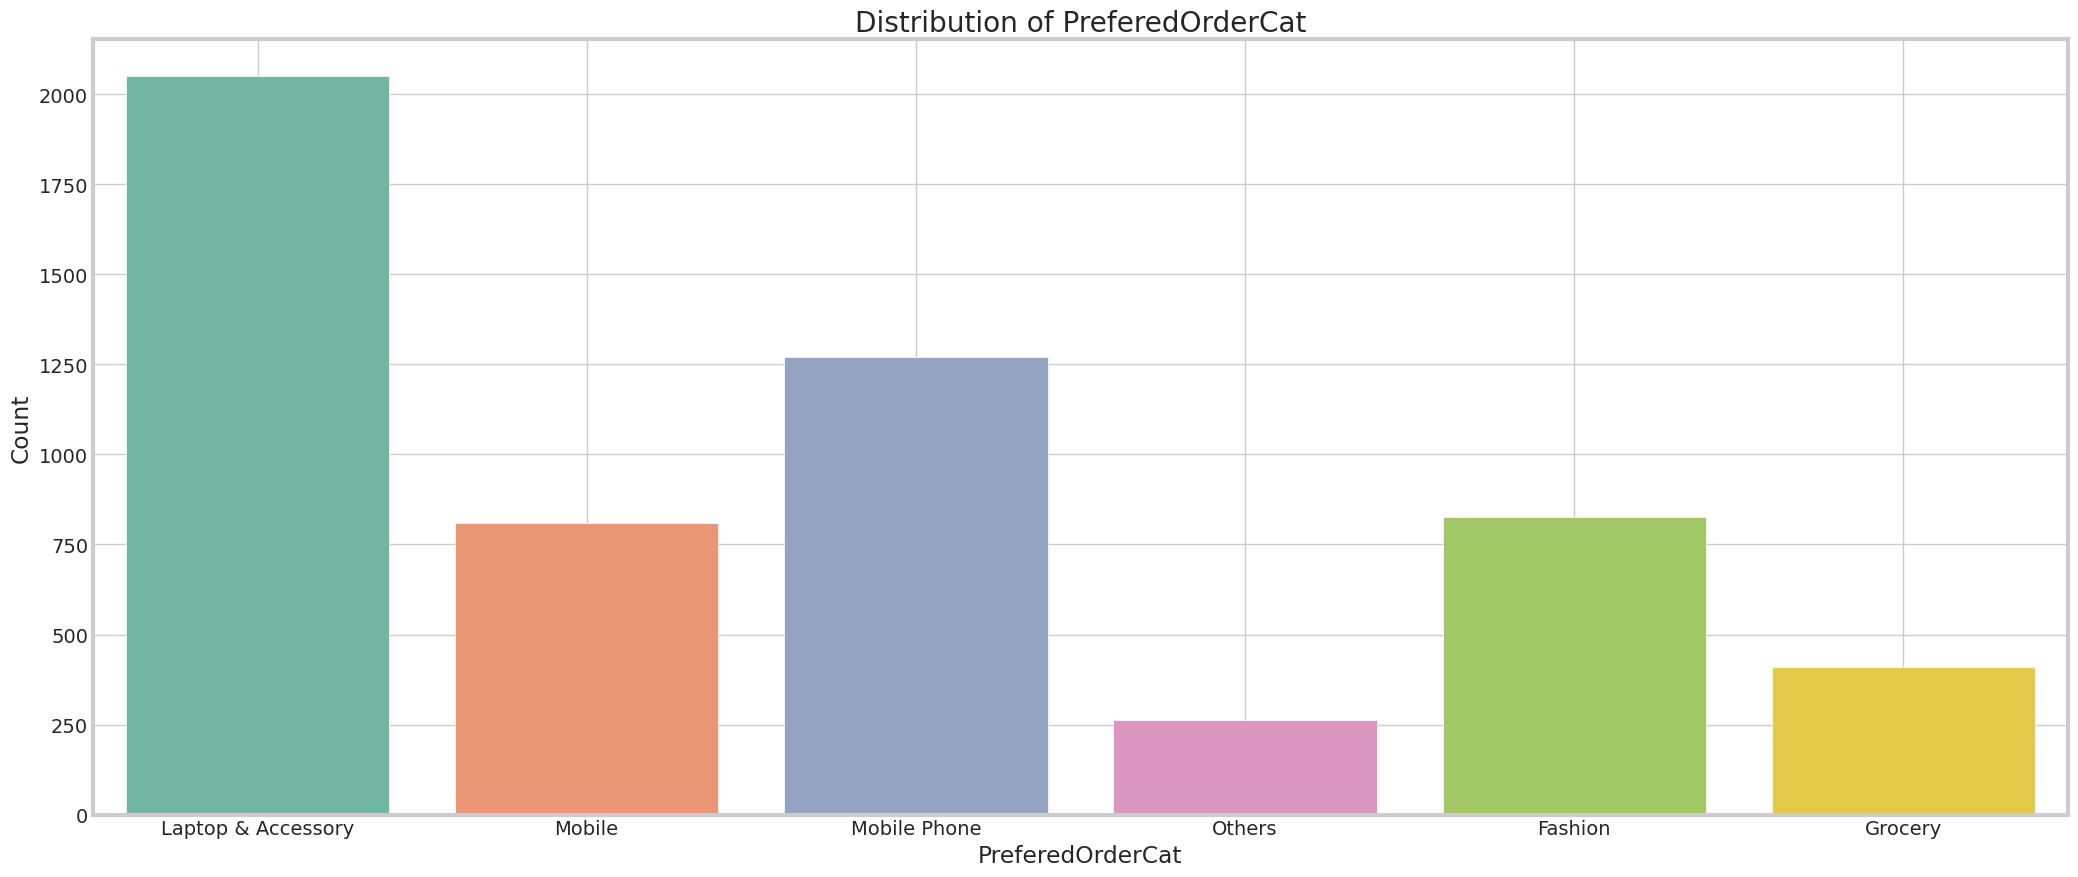

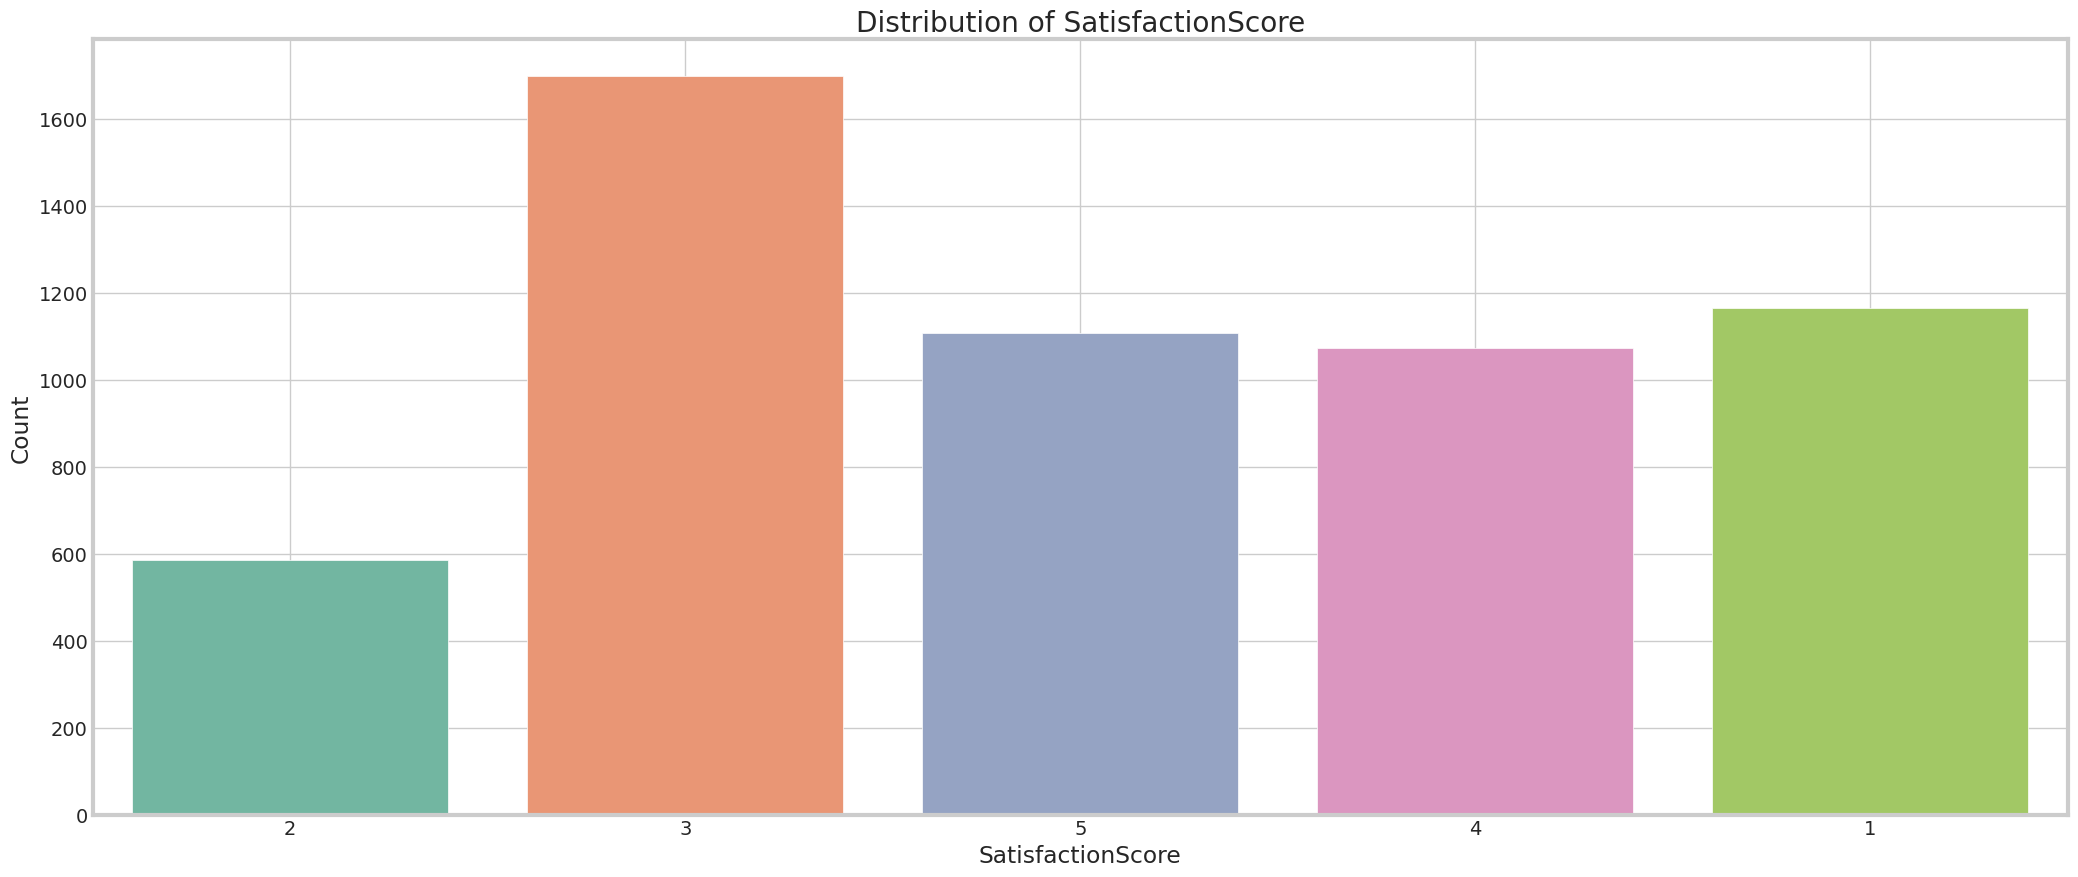

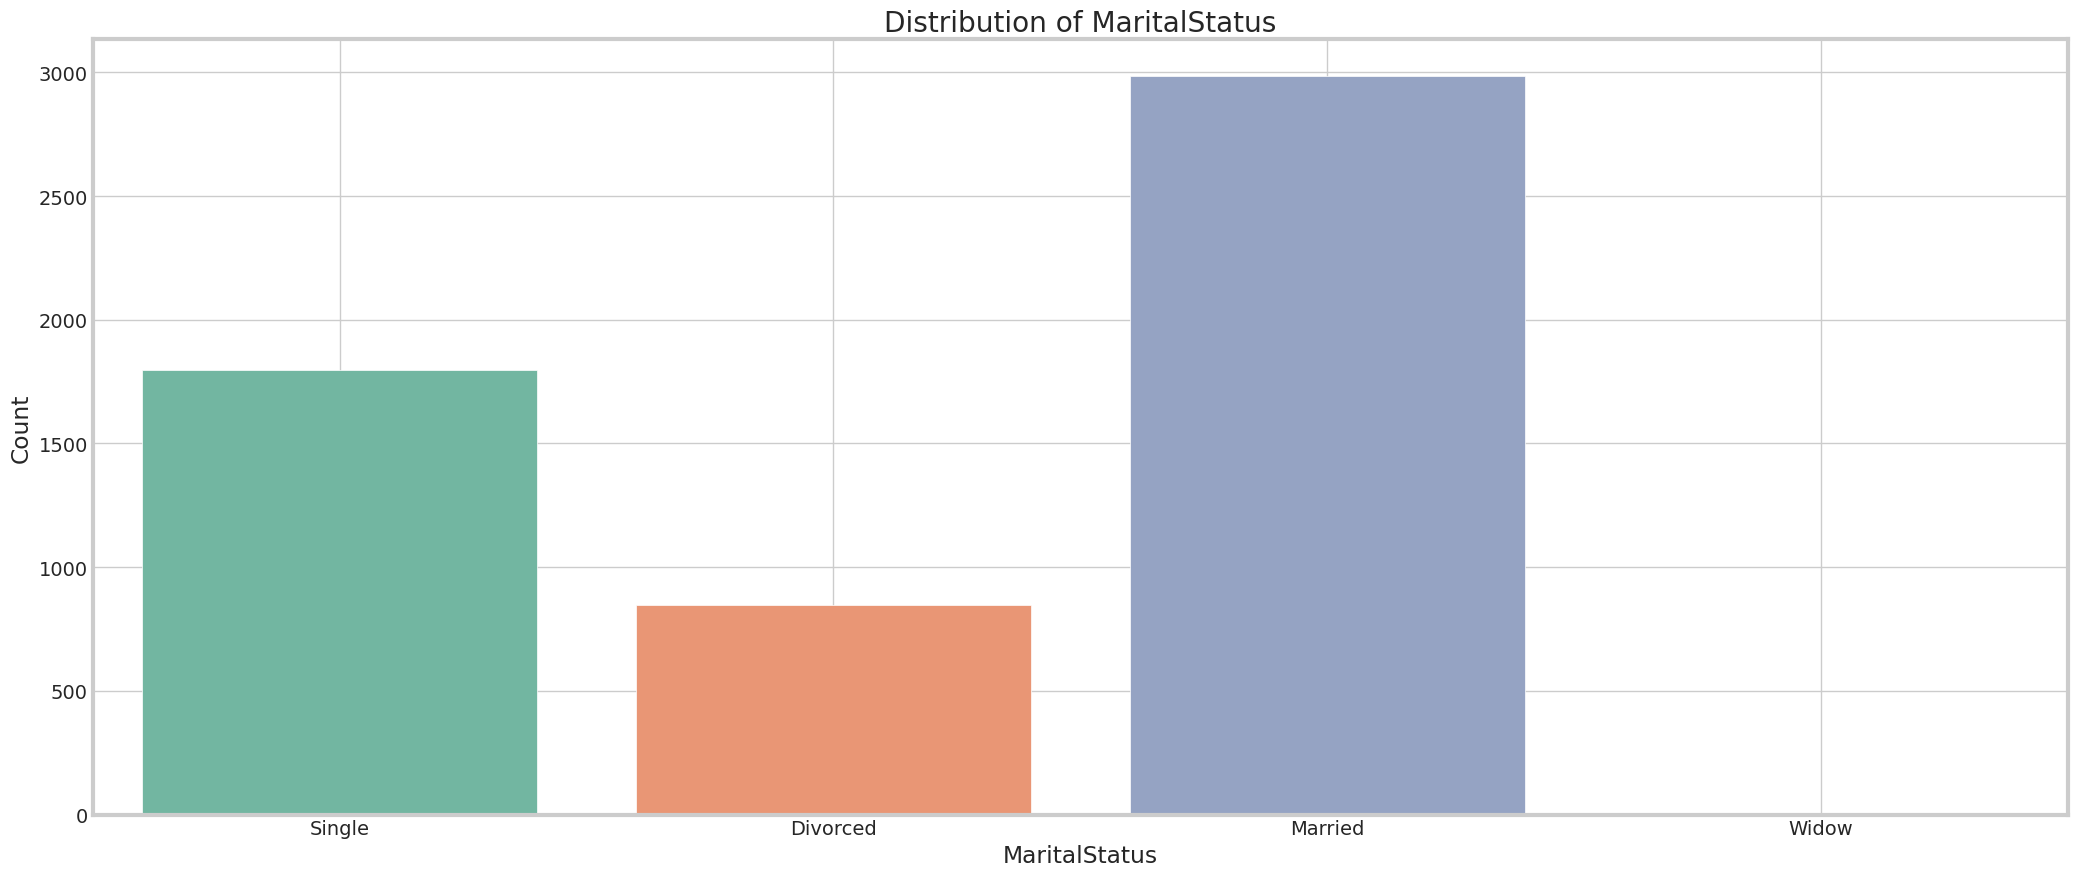

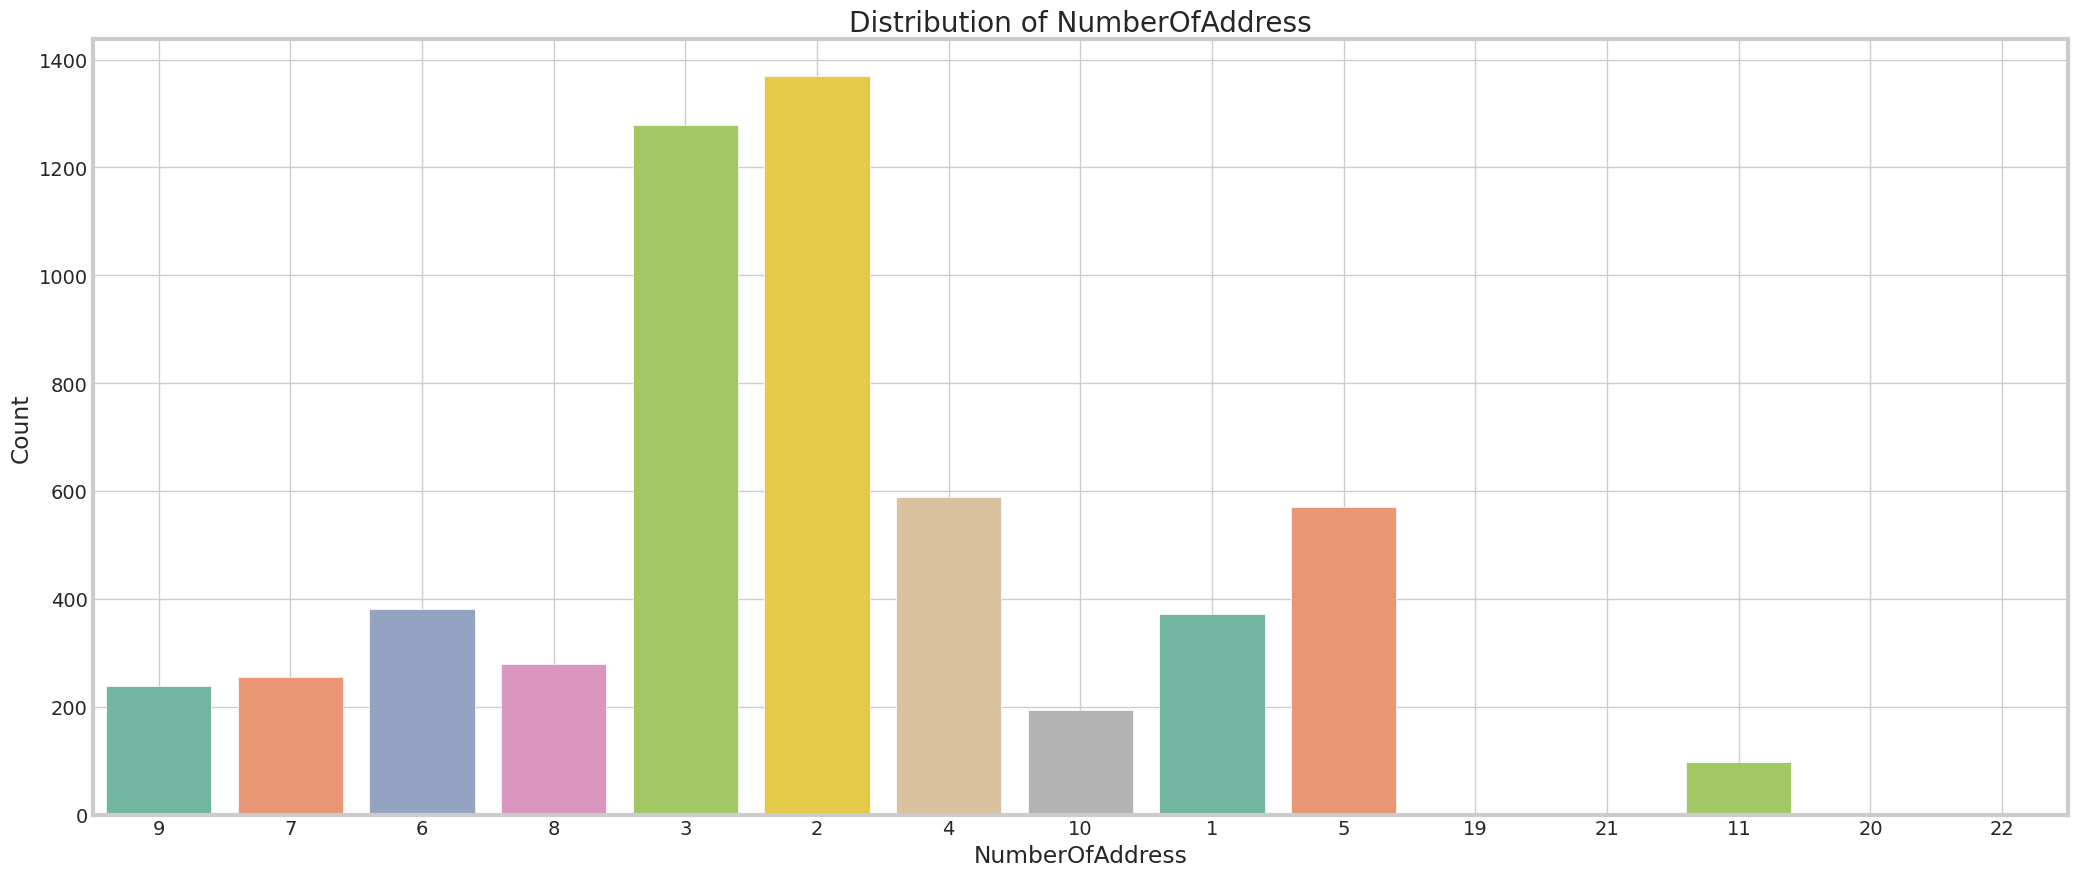

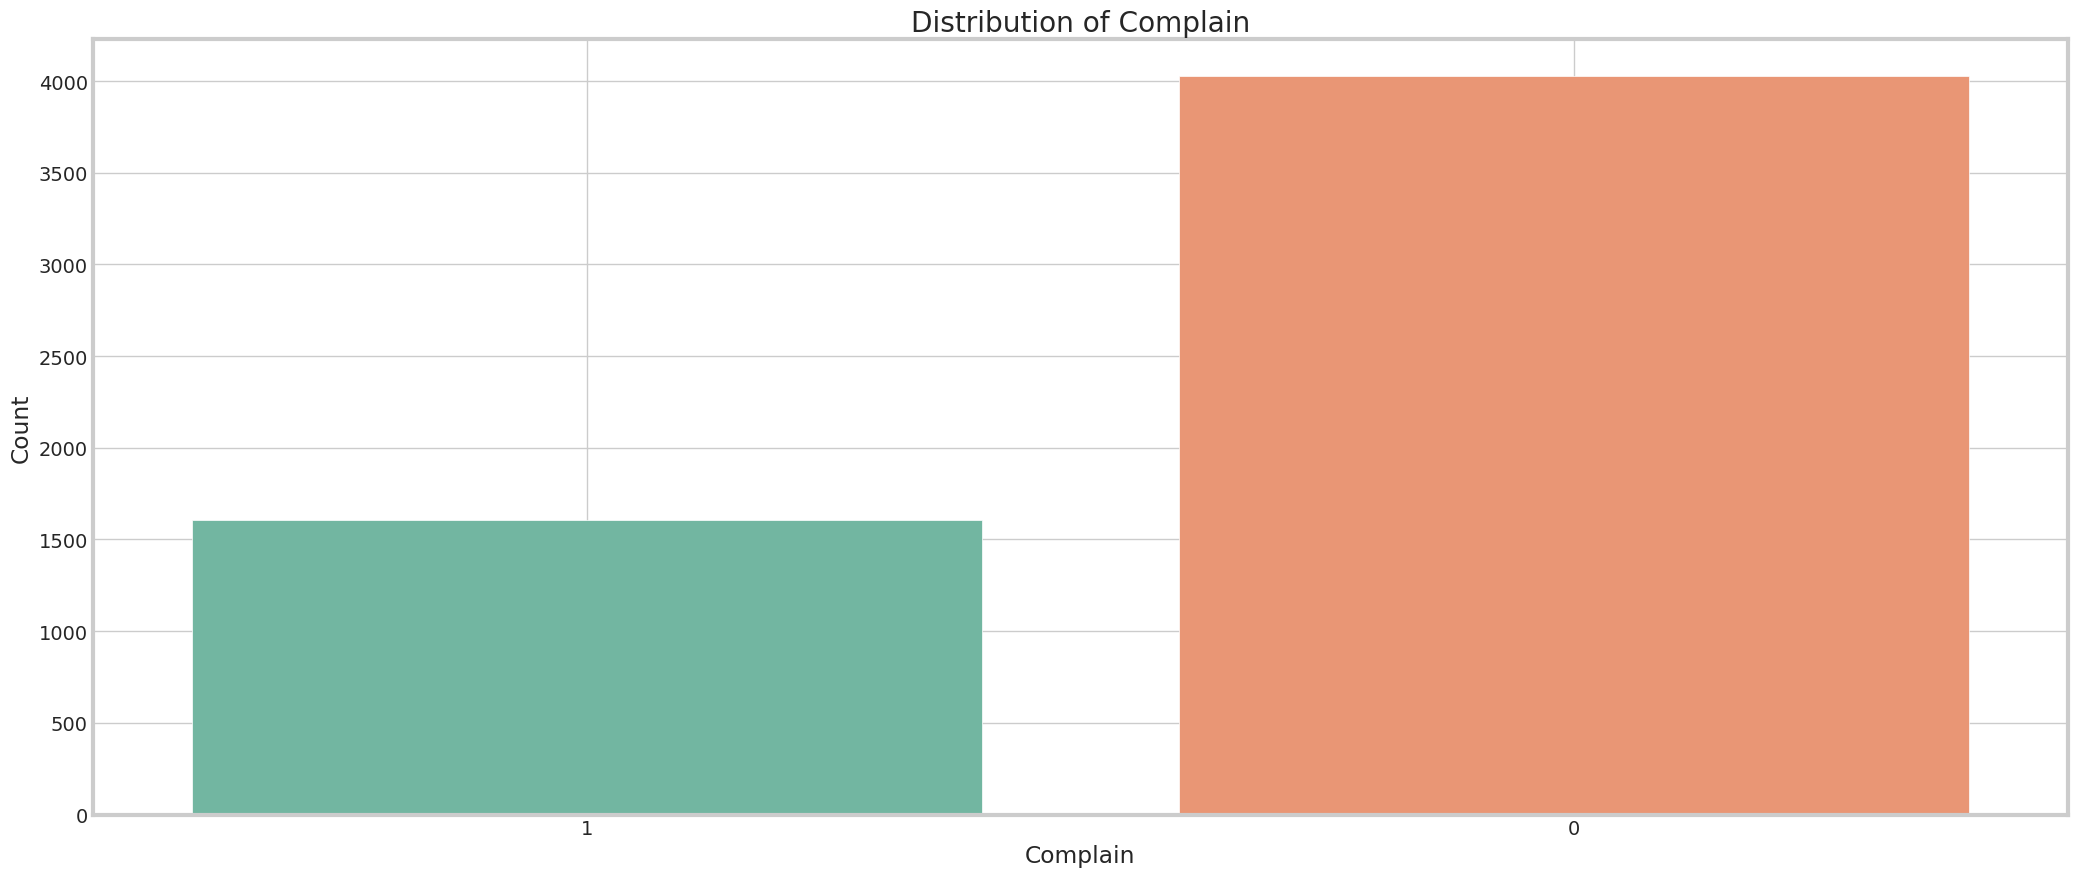

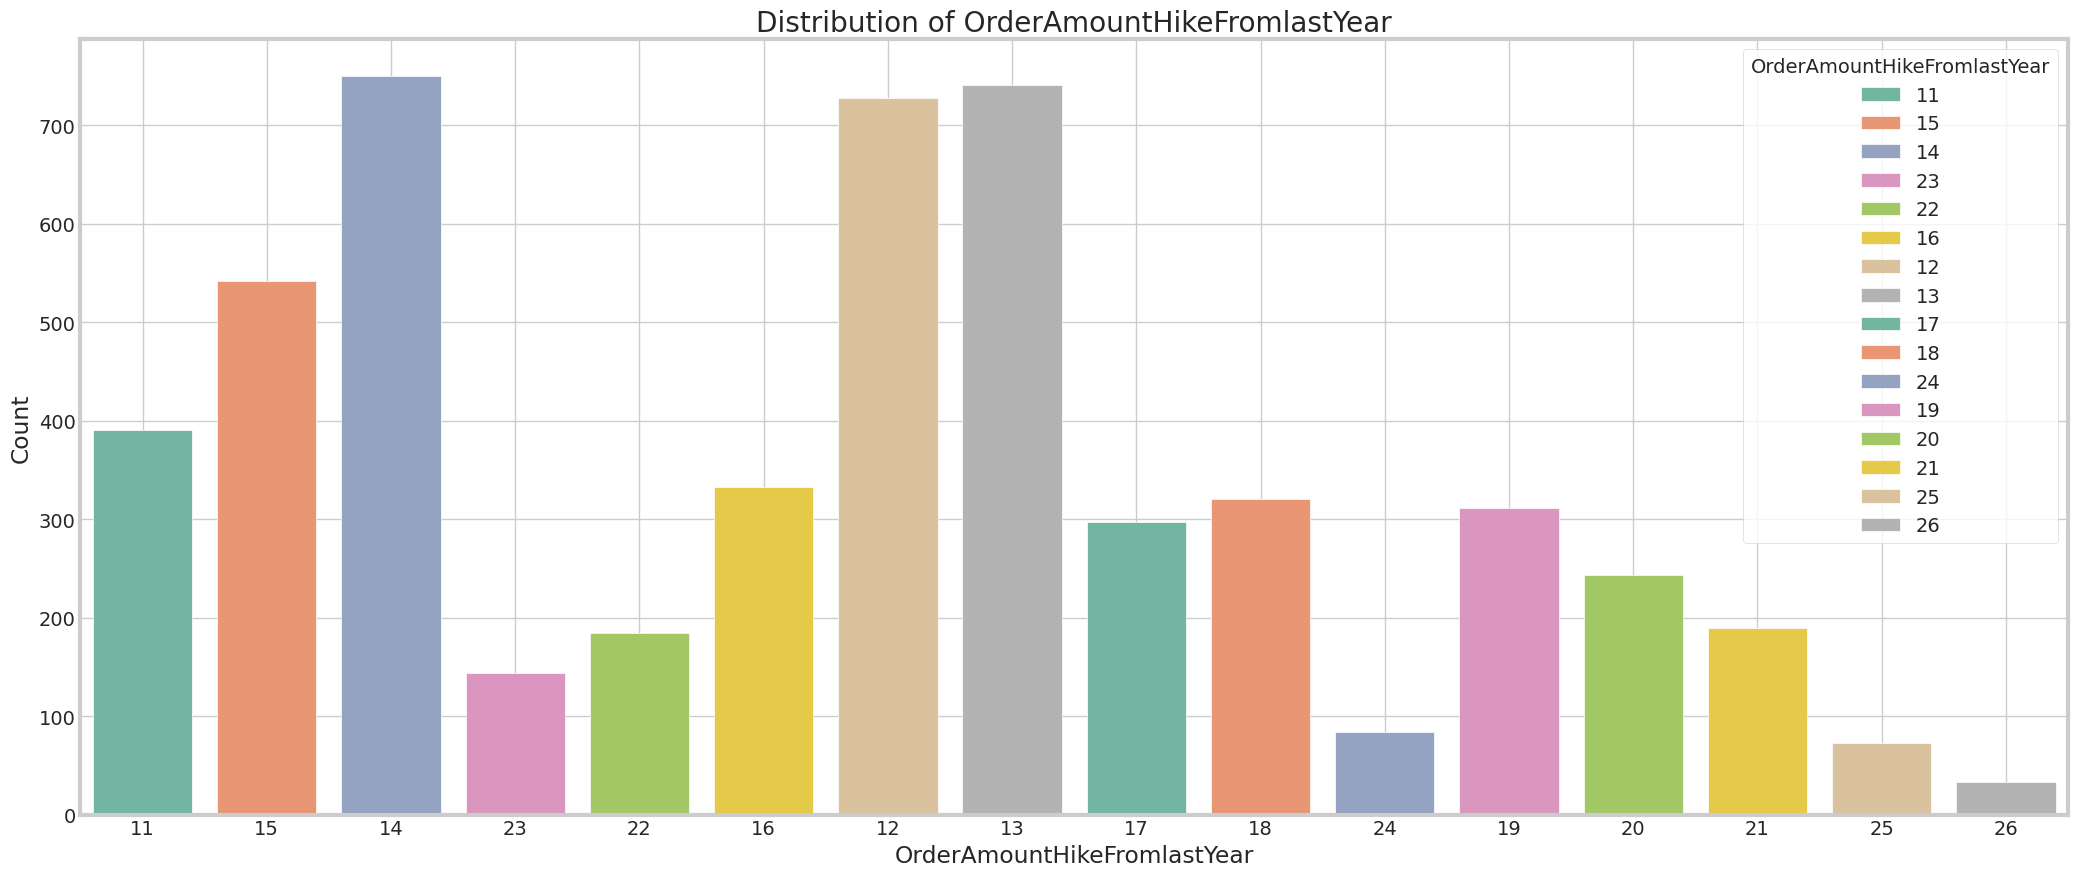

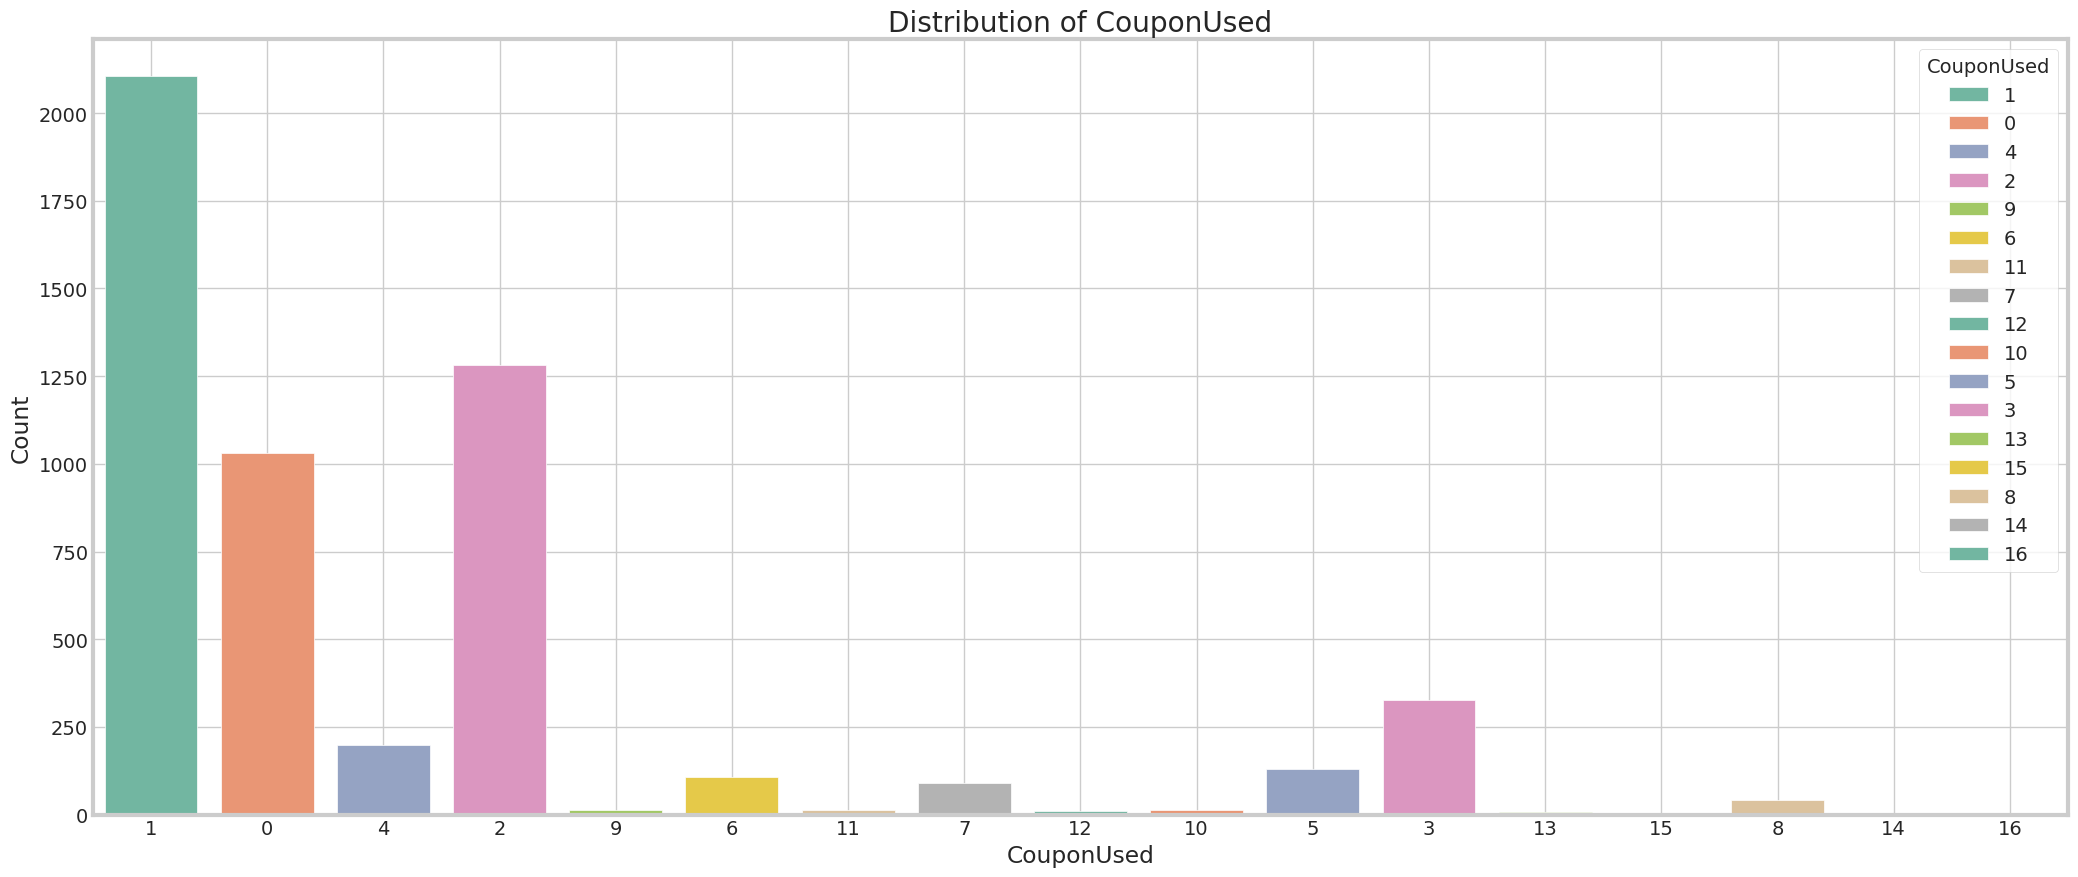

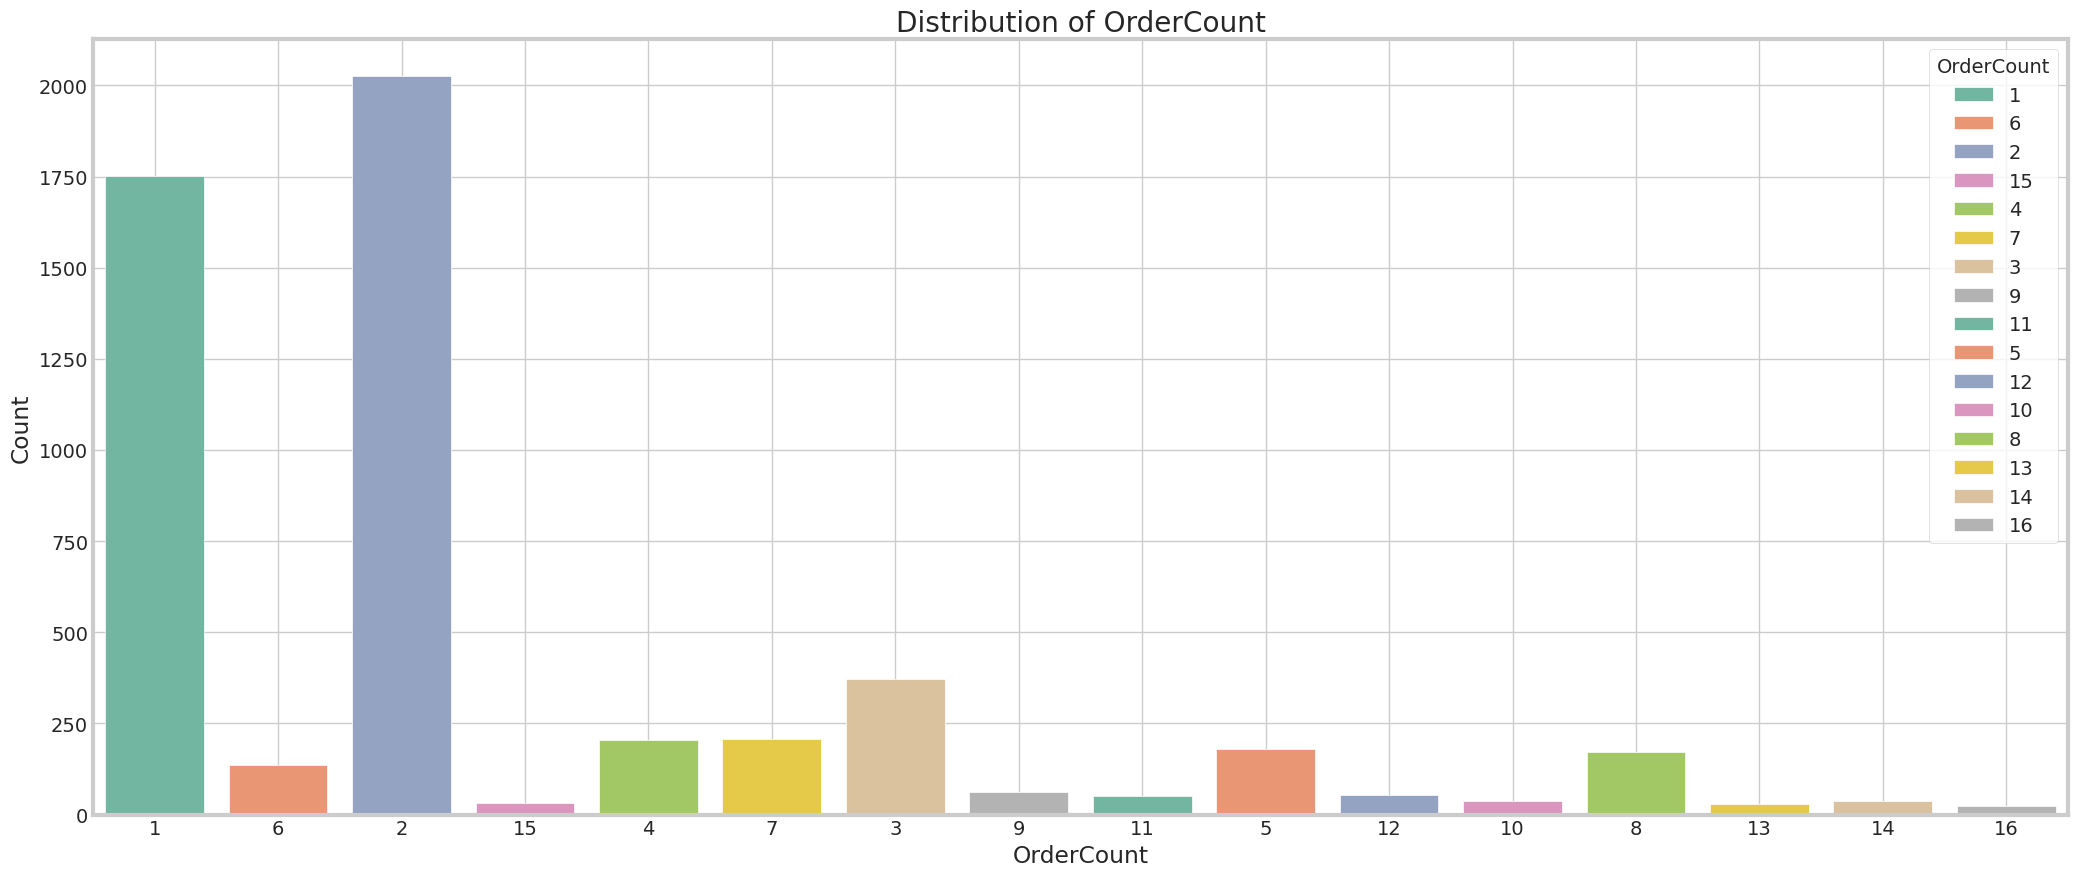

In [71]:
# Visualize the distribution of categorical features

for feature in categorical_cols:
    plt.figure(figsize=(21, 9))
    sns.countplot(x=feature, hue=feature, data=df_raw, palette='Set2')
    plt.style.use('fivethirtyeight')
    sns.set_style("whitegrid")
    plt.grid(True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')

    plt.tight_layout()

    plt.show()





 Numerical variables and their distribution

In [72]:
for column in numerical_cols:
        print("Column: {} - Unique Values: {}".format(column, df_raw[column].unique()))
        print("="*80)

Column: Tenure - Unique Values: [ 4. nan  0. 13. 11.  9. 19. 20. 14.  8. 18.  5.  2. 30.  1. 23.  3. 29.
  6. 26. 28.  7. 24. 25. 10. 15. 22. 27. 16. 12. 21. 17. 50. 60. 31. 51.
 61.]
Column: WarehouseToHome - Unique Values: [  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  nan  10.  27.  17.  23.  33.  19.  35.  24.  16.  25.  32.
  34.   5.  21. 126.   7.  36. 127.]
Column: DaySinceLastOrder - Unique Values: [ 5.  0.  3.  7.  2.  1.  8.  6.  4. 15.  9. 11. 10. nan 13. 12. 17. 16.
 14. 30. 46. 18. 31.]
Column: CashbackAmount - Unique Values: [159.93 120.9  120.28 ... 173.77 287.91 173.78]


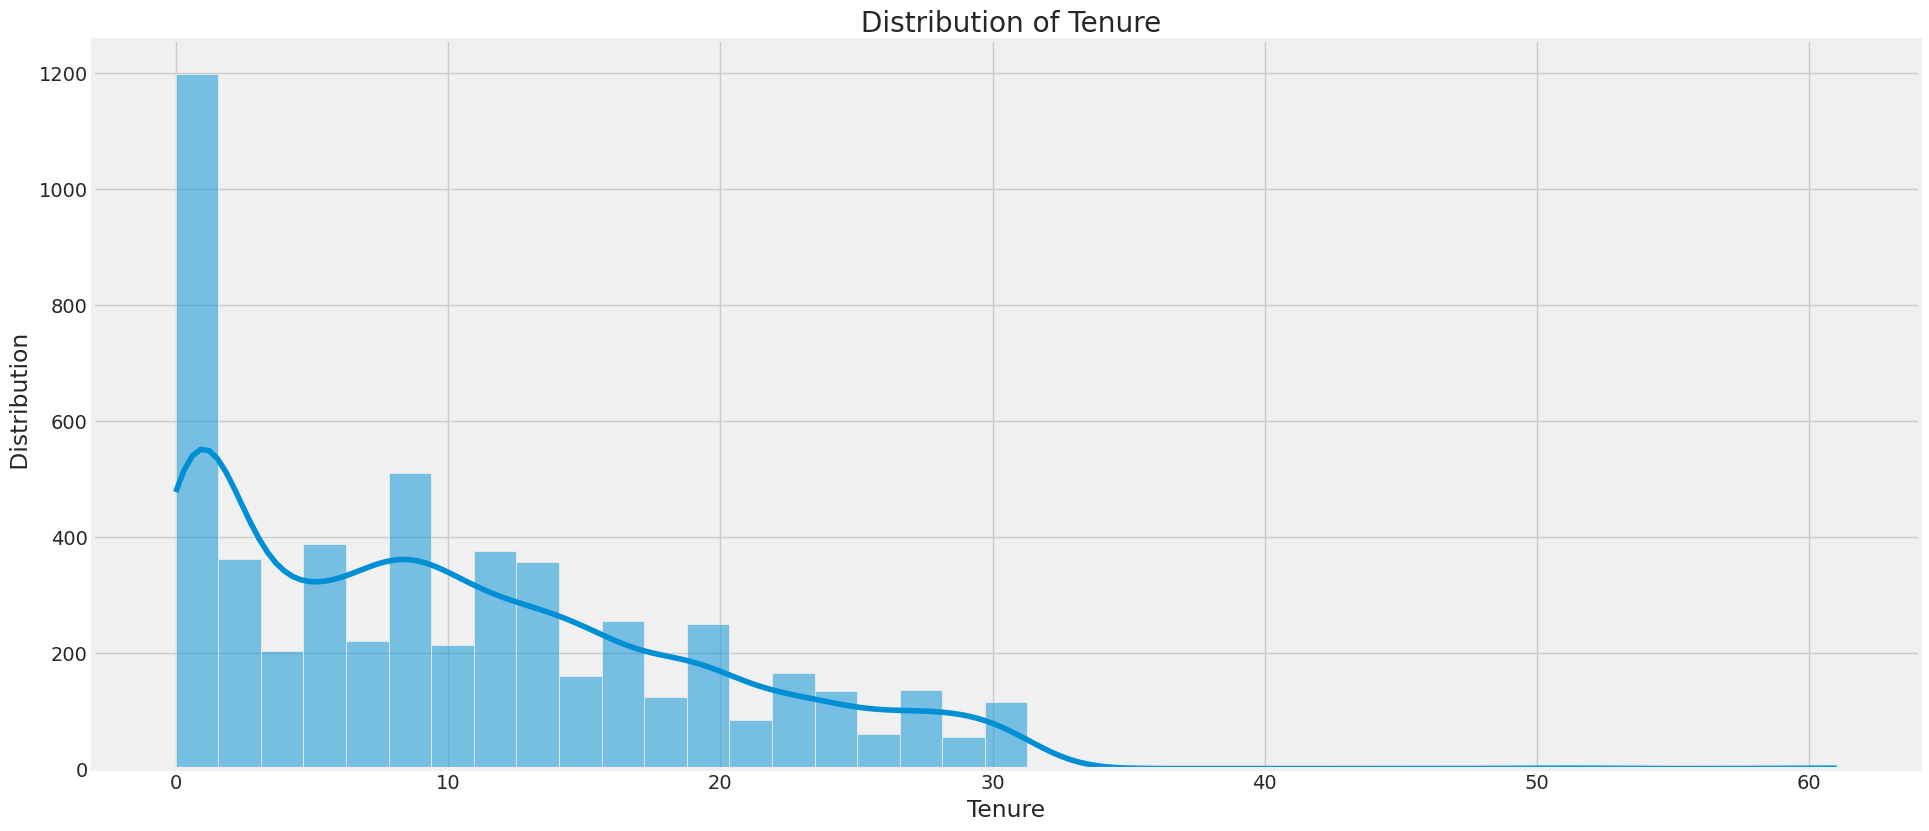

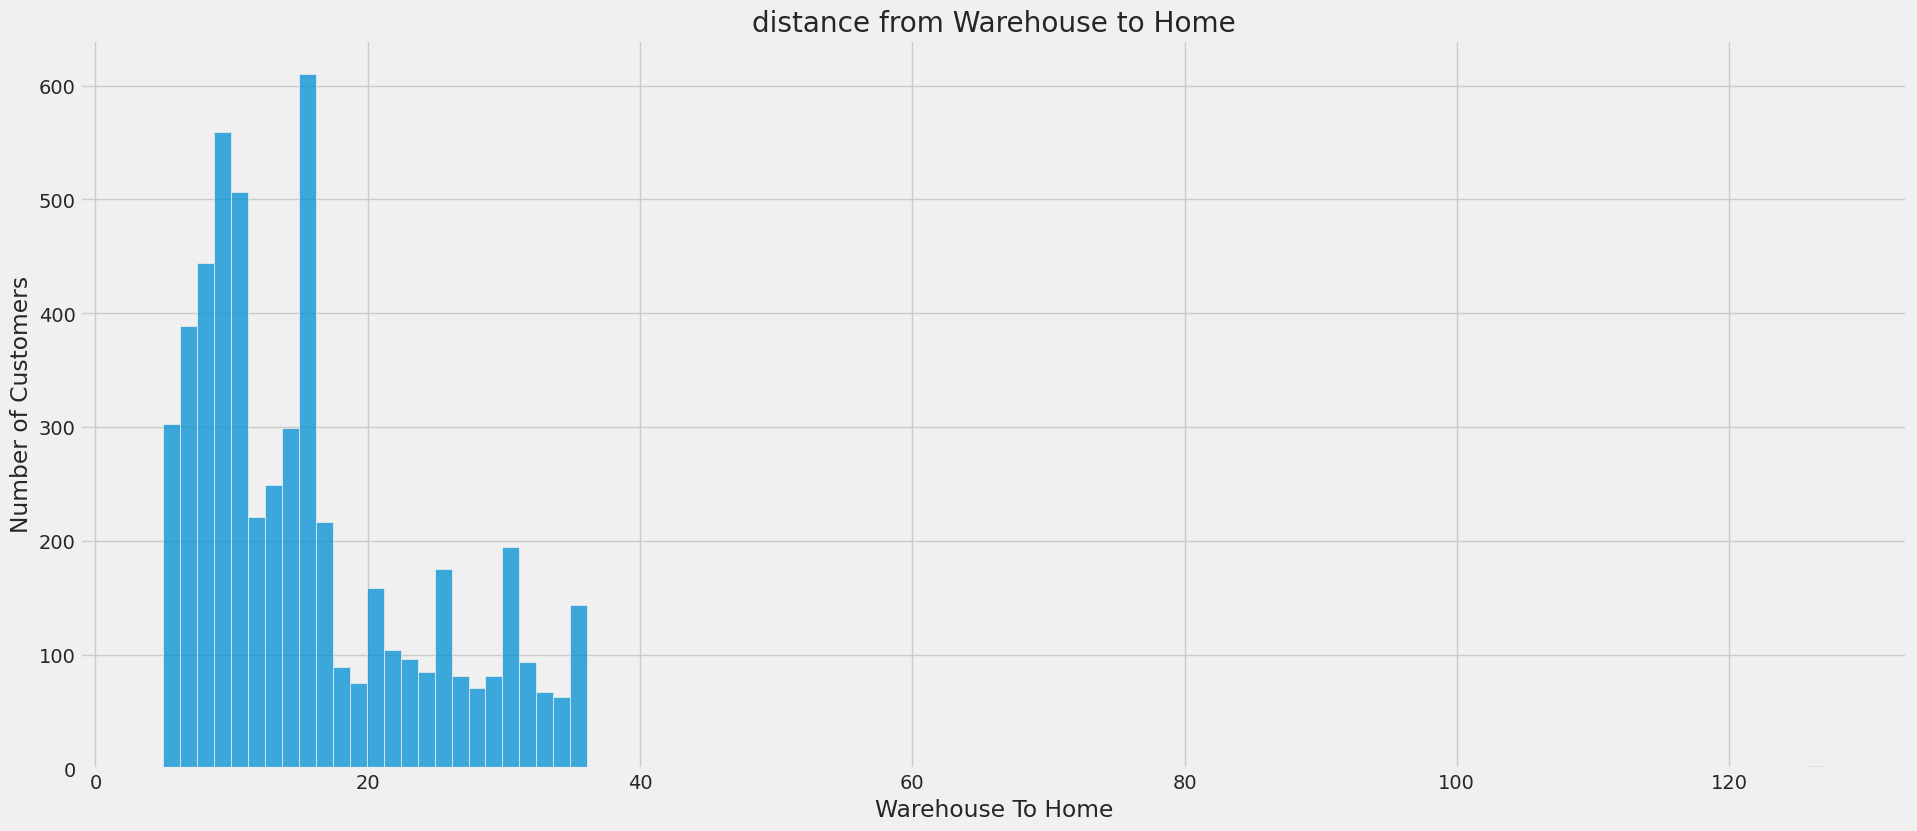

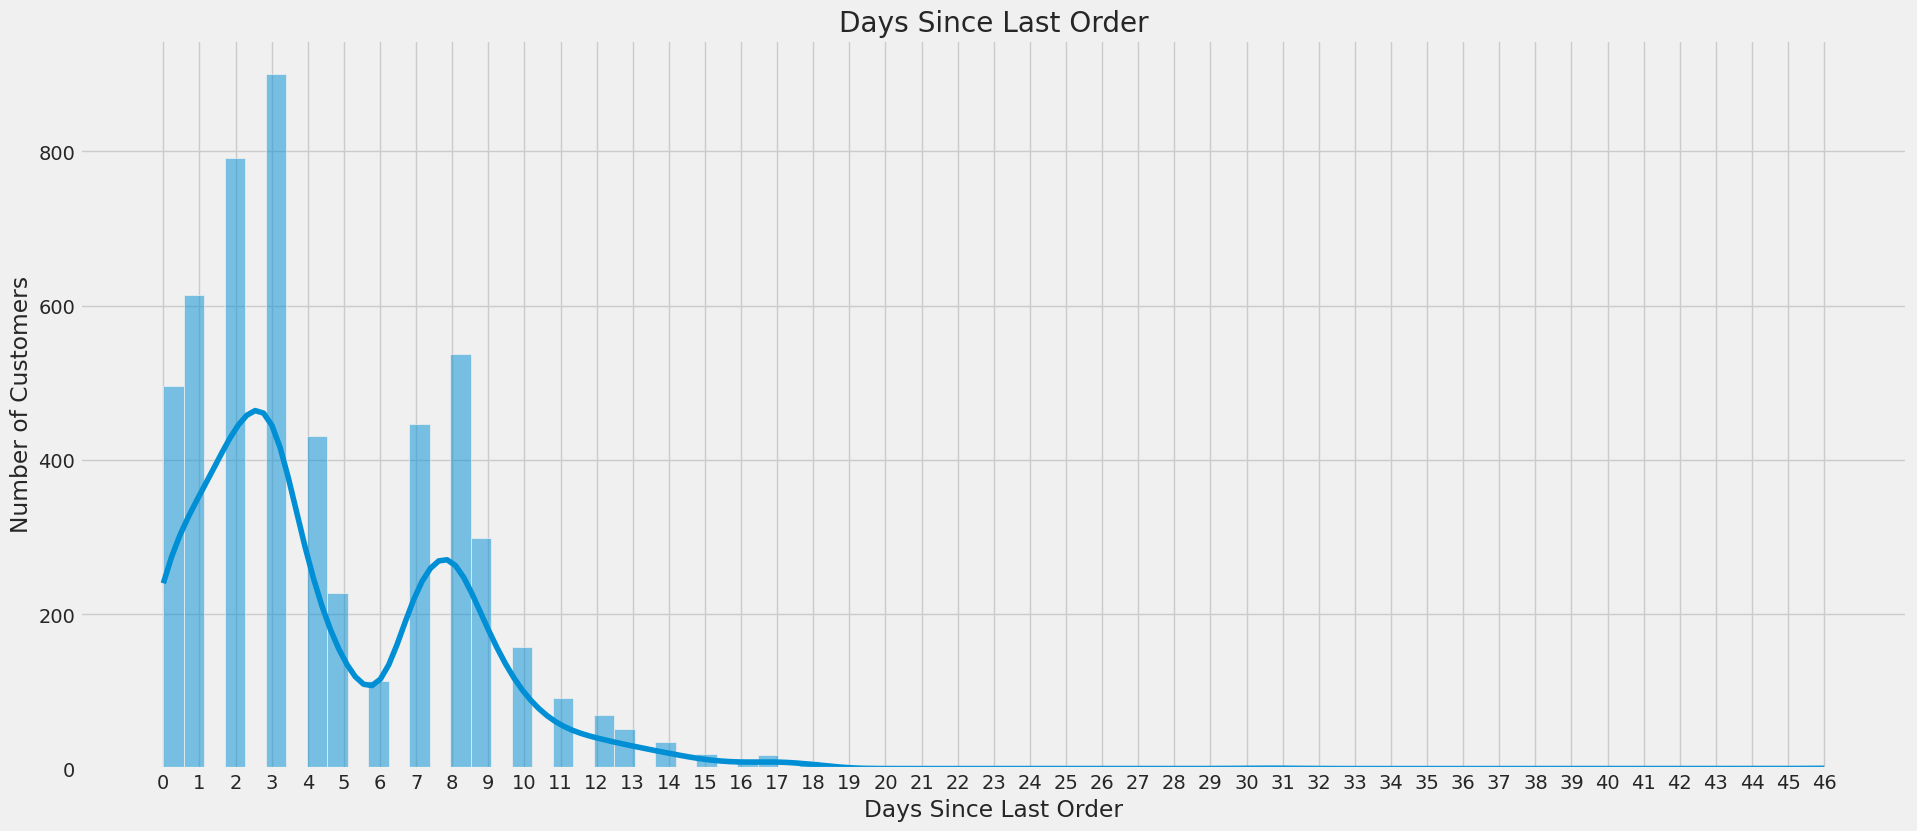

In [73]:
# Visualize the distribution of numerical features

# Tenure
plt.figure(figsize=(21, 9))
plt.style.use('fivethirtyeight')
sns.histplot(x='Tenure', data=df_raw, kde=True)
plt.xlabel('Tenure')
plt.ylabel(' Distribution')
plt.title(' Distribution of Tenure')
plt.show()

# warehouseToHome
plt.figure(figsize=(21, 9))
plt.style.use('fivethirtyeight')
sns.histplot(x='WarehouseToHome', data=df_raw)
plt.title('distance from Warehouse to Home')
plt.xlabel('Warehouse To Home')
plt.ylabel('Number of Customers')
plt.show()

# DaySinceLastOrder
plt.figure(figsize=(21, 9))
sns.histplot(x='DaySinceLastOrder', data=df_raw, kde=True)
plt.xticks(np.arange(0, df_raw['DaySinceLastOrder'].max() + 1, 1))
plt.style.use('fivethirtyeight')
sns.set_style("whitegrid")
plt.grid(True)
plt.title('Days Since Last Order')
plt.xlabel('Days Since Last Order')
plt.ylabel('Number of Customers')
plt.show()


In [74]:
# Display descriptive statistics for numerical columns
df_raw[numerical_cols].describe(percentiles=[.01,.1,.25,.5,.75,.90,.95,.99]).T

,count,mean,std,min,1%,10%,25%,50%,75%,90%,95%,99%,max
Tenure,5366.0,10.189899,8.557241,0.0,0.00,1.00,2.00,9.00,16.0000,23.00,27.0000,30.0000,61.0
WarehouseToHome,5379.0,15.639896,8.531475,5.0,6.00,7.00,9.00,14.00,20.0000,30.00,33.0000,35.0000,127.0
DaySinceLastOrder,5323.0,4.543491,3.654433,0.0,0.00,1.00,2.00,3.00,7.0000,9.00,11.0000,15.0000,46.0
CashbackAmount,5630.0,532.401057,18842.837049,0.0,116.01,126.86,145.77,163.33,196.4225,259.92,291.9975,319.0194,999999.0


Text(0.5, 1.0, 'Correlation Matrix Heatmap')

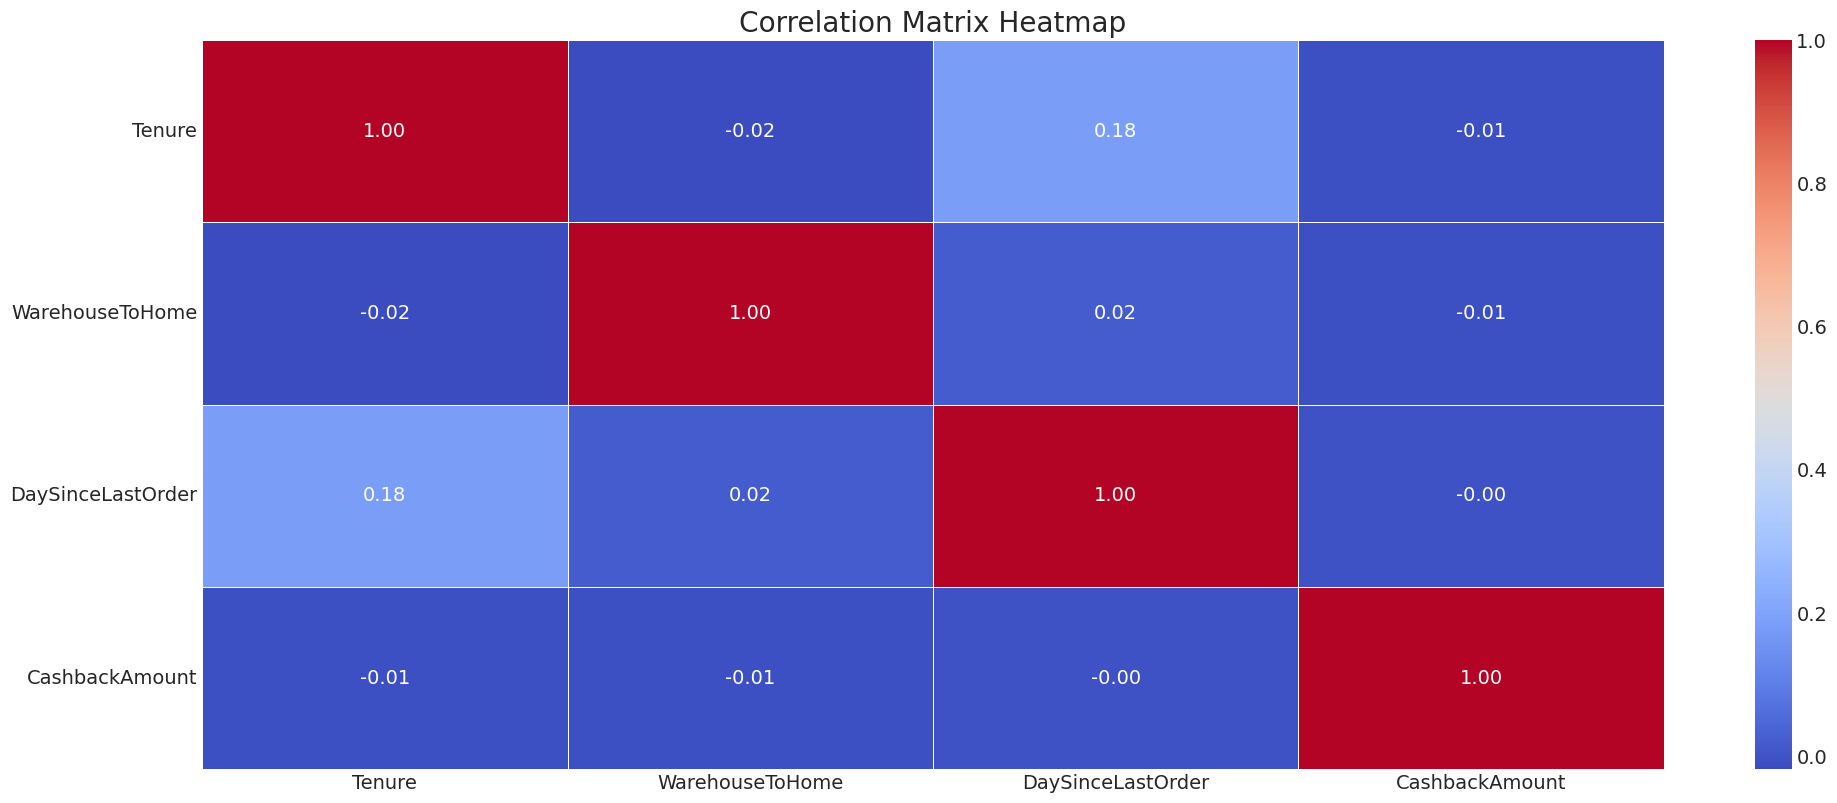

In [75]:
#heatmap of correlation matrix
plt.figure(figsize=(21, 9))
sns.heatmap(df_raw[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')

### **4. Data Cleaning & Preprocessing**

In [76]:
# Introduce some NaN values to test imputation
for col in ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear',
            'CouponUsed', 'OrderCount', 'DaySinceLastOrder']:
    df_raw.loc[df_raw.sample(frac=0.05).index, col] = np.nan

# Create a copy of the raw DataFrame for cleaning
df_clean = df_raw.copy()


In [77]:
# Drop rows with missing essential identifiers
df_clean.dropna(subset=['CustomerID'], inplace=True)
# Drop rows with missing essential identifiers
df_clean.dropna(subset=['Gender'], inplace=True)

# Find duplicate CustomerID rows (excluding the first occurrence)
duplicates = df_clean[df_clean.duplicated('CustomerID')]
# Remove duplicate CustomerID rows, keeping the first occurrence
df_clean = df_clean.drop_duplicates(subset='CustomerID', keep='first')

# Only keep numerical columns that exist in df_clean
existing_numerical_cols = [col for col in numerical_cols if col in df_clean.columns]

In [78]:
# List of columns with missing values to impute
cols_to_impute = [
    'HourSpendOnApp','OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount'
]

# Impute  columns with mean
imputer = SimpleImputer(strategy='mean')
df_clean[cols_to_impute] = imputer.fit_transform(df_clean[cols_to_impute])

# Impute numerical values with median
imputer_median = SimpleImputer(strategy='median')
df_clean['Tenure'] = imputer_median.fit_transform(df_clean[['Tenure']])
df_clean['WarehouseToHome'] = imputer_median.fit_transform(df_clean[['WarehouseToHome']])
df_clean['DaySinceLastOrder'] = imputer_median.fit_transform(df_clean[['DaySinceLastOrder']])



In [79]:
df_clean.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0


In [80]:
# Save the cleaned DataFrame to an Excel file
df_clean.to_excel("cleaned_data.xlsx", index=False)

In [81]:
# Display the shape of the cleaned DataFrame
df_clean.shape

(5626, 20)

### **5. Model Selection and Trainning**

In [82]:
# 1. Prepare data

df_model = df_clean.copy()
df_model.drop(columns=["CustomerID"], inplace=True, errors="ignore")

# If Churn is already numeric, just clean missing values
df_model = df_model.dropna(subset=["Churn"]).copy()
df_model["Churn"] = df_model["Churn"].astype(int)

y = df_model["Churn"]
X = df_model.drop(columns=["Churn"])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Categorical columns: ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain']
X_train shape: (4500, 18)
X_test shape: (1126, 18)


**Trainning baseline XGBoost**

In [83]:
# 2. Prepare data for XGBoost
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

if categorical_cols:
    X_train_xgb[categorical_cols] = encoder.fit_transform(X_train_xgb[categorical_cols].astype(str))
    X_test_xgb[categorical_cols] = encoder.transform(X_test_xgb[categorical_cols].astype(str))

X_train_xgb = X_train_xgb.astype(float)
X_test_xgb = X_test_xgb.astype(float)

In [84]:
#  Train baseline XGBoost model

xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_baseline.fit(X_train_xgb, y_train)

print("Baseline XGBoost trained successfully.")

Baseline XGBoost trained successfully.


**Trainning baseline CatBoost model**

In [85]:
# 3. Prepare data for CatBoost
# (CatBoost can use raw categorical features directly)
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

for col in categorical_cols:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

catboost_train_pool = Pool(X_train_cat, y_train, cat_features=categorical_cols)
catboost_test_pool = Pool(X_test_cat, y_test, cat_features=categorical_cols)

In [86]:
# Train baseline CatBoost model
catboost_baseline = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

catboost_baseline.fit(catboost_train_pool)

print("Baseline CatBoost trained successfully.")

Baseline CatBoost trained successfully.


### **6. Hyperparameter Tuning**

 **HYPERPARAMETER TUNING for XGBOOST**

In [87]:
# HYPERPARAMETER TUNING (XGBOOST)

# DMatrix for XGBoost CV
train_dmatrix = xgb.DMatrix(X_train_xgb, label=y_train)

N_FOLDS = 5
MAX_EVALS = 15

In [88]:
# Search space
hyperparameter_space = {
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 0.8),
    "subsample": hp.uniform("subsample", 0.6, 0.8),
    "min_child_weight": hp.quniform("min_child_weight", 1, 7, 2),
    "reg_alpha": hp.uniform("reg_alpha", 0.0, 1.0),
    "reg_lambda": hp.uniform("reg_lambda", 0.0, 1.0),
    "max_depth": hp.randint("max_depth", 3, 10),
    "gamma": hp.uniform("gamma", 0.0, 0.5),
    "max_delta_step": hp.randint("max_delta_step", 0, 10),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.01), np.log(0.2))
}

In [89]:
def objective(params):
    params = params.copy()

    # Hyperopt may return floats for some integer-like params
    params["max_depth"] = int(params["max_depth"])
    params["max_delta_step"] = int(params["max_delta_step"])
    params["min_child_weight"] = int(params["min_child_weight"])

    params["objective"] = "binary:logistic"
    params["eval_metric"] = "auc"
    params["tree_method"] = "hist"
    params["seed"] = 42
    params["nthread"] = -1

    cv_results = xgb.cv(
        params=params,
        dtrain=train_dmatrix,
        nfold=N_FOLDS,
        num_boost_round=500,
        early_stopping_rounds=30,
        metrics="auc",
        as_pandas=True,
        seed=42
    )

    best_auc = cv_results["test-auc-mean"].max()
    best_n_estimators = cv_results["test-auc-mean"].idxmax() + 1

    return {
        "loss": 1 - best_auc,
        "status": STATUS_OK,
        "n_estimators": best_n_estimators
    }

In [90]:
bayes_trials = Trials()

best = fmin(
    fn=objective,
    space=hyperparameter_space,
    algo=tpe.suggest,
    max_evals=MAX_EVALS,
    trials=bayes_trials,
    rstate=np.random.default_rng(42)
)

print("Best hyperparameters from Hyperopt:")
print(best)

100%|██████████| 15/15 [00:59<00:00,  3.96s/trial, best loss: 0.031132527246163]
Best hyperparameters from Hyperopt:
{'colsample_bytree': np.float64(0.6394447041718989), 'gamma': np.float64(0.2604518181531908), 'learning_rate': np.float64(0.062293247467364414), 'max_delta_step': np.int64(8), 'max_depth': np.int64(8), 'min_child_weight': np.float64(2.0), 'reg_alpha': np.float64(0.6091041490883193), 'reg_lambda': np.float64(0.730039600362054), 'subsample': np.float64(0.6566321876060209)}


In [91]:
# Clean best params
best_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "colsample_bytree": best["colsample_bytree"],
    "subsample": best["subsample"],
    "min_child_weight": int(best["min_child_weight"]),
    "reg_alpha": best["reg_alpha"],
    "reg_lambda": best["reg_lambda"],
    "max_depth": int(best["max_depth"]),
    "gamma": best["gamma"],
    "max_delta_step": int(best["max_delta_step"]),
    "learning_rate": best["learning_rate"]
}

best_trial = min(bayes_trials.results, key=lambda x: x["loss"])
best_n_estimators = best_trial["n_estimators"]

print("Best params for final XGBoost model:")
print(best_params)
print("Best n_estimators:", best_n_estimators)

Best params for final XGBoost model:
{'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'random_state': 42, 'colsample_bytree': np.float64(0.6394447041718989), 'subsample': np.float64(0.6566321876060209), 'min_child_weight': 2, 'reg_alpha': np.float64(0.6091041490883193), 'reg_lambda': np.float64(0.730039600362054), 'max_depth': 8, 'gamma': np.float64(0.2604518181531908), 'max_delta_step': 8, 'learning_rate': np.float64(0.062293247467364414)}
Best n_estimators: 310


In [92]:
# Train tuned XGBoost model
xgb_best = XGBClassifier(
    **best_params,
    n_estimators=best_n_estimators
)

xgb_best.fit(X_train_xgb, y_train)

print("Tuned XGBoost model trained successfully.")

Tuned XGBoost model trained successfully.


**HYPERPARAMETER TUNING CATBOOST**

In [93]:
# Search space for CatBoost
catboost_space = {
    "depth": hp.randint("depth", 4, 11),  # 4 to 10
    "learning_rate": hp.loguniform("cb_learning_rate", np.log(0.01), np.log(0.2)),
    "l2_leaf_reg": hp.uniform("l2_leaf_reg", 1, 10),
    "bagging_temperature": hp.uniform("bagging_temperature", 0, 1),
    "random_strength": hp.uniform("random_strength", 0, 2),
    "border_count": hp.randint("border_count", 32, 256),
    "iterations": hp.randint("iterations", 100, 500)
}

In [94]:
def catboost_objective(params):
    params = params.copy()

    params["depth"] = int(params["depth"])
    params["border_count"] = int(params["border_count"])
    params["iterations"] = int(params["iterations"])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, valid_idx in skf.split(X_train_cat, y_train):
        X_fold_train = X_train_cat.iloc[train_idx].copy()
        X_fold_valid = X_train_cat.iloc[valid_idx].copy()
        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]

        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=42,
            verbose=0,
            **params
        )

        model.fit(
            X_fold_train,
            y_fold_train,
            cat_features=categorical_cols
        )

        y_valid_prob = model.predict_proba(X_fold_valid)[:, 1]
        auc = roc_auc_score(y_fold_valid, y_valid_prob)
        auc_scores.append(auc)

    mean_auc = np.mean(auc_scores)

    return {
        "loss": 1 - mean_auc,
        "status": STATUS_OK
    }

In [95]:
cat_trials = Trials()

best_cat = fmin(
    fn=catboost_objective,
    space=catboost_space,
    algo=tpe.suggest,
    max_evals=15,
    trials=cat_trials,
    rstate=np.random.default_rng(42)
)

print("Best CatBoost hyperparameters:")
print(best_cat)

100%|██████████| 15/15 [05:10<00:00, 20.67s/trial, best loss: 0.028509101968322903]
Best CatBoost hyperparameters:
{'bagging_temperature': np.float64(0.5007506098950729), 'border_count': np.int64(212), 'cb_learning_rate': np.float64(0.08251323454296797), 'depth': np.int64(8), 'iterations': np.int64(355), 'l2_leaf_reg': np.float64(2.909954052940017), 'random_strength': np.float64(0.8075553405239584)}


In [96]:
# Clean best CatBoost params
best_cat_params = {
    "depth": int(best_cat["depth"]),
    "learning_rate": best_cat["cb_learning_rate"],
    "l2_leaf_reg": best_cat["l2_leaf_reg"],
    "bagging_temperature": best_cat["bagging_temperature"],
    "random_strength": best_cat["random_strength"],
    "border_count": int(best_cat["border_count"]),
    "iterations": int(best_cat["iterations"]),
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": 42,
    "verbose": 0
}

print("Best params for final CatBoost model:")
print(best_cat_params)

Best params for final CatBoost model:
{'depth': 8, 'learning_rate': np.float64(0.08251323454296797), 'l2_leaf_reg': np.float64(2.909954052940017), 'bagging_temperature': np.float64(0.5007506098950729), 'random_strength': np.float64(0.8075553405239584), 'border_count': 212, 'iterations': 355, 'loss_function': 'Logloss', 'eval_metric': 'AUC', 'random_seed': 42, 'verbose': 0}


In [97]:
# Train tuned CatBoost model
catboost_best = CatBoostClassifier(
    **best_cat_params,
    cat_features=categorical_cols
)

catboost_best.fit(X_train_cat, y_train)

print("Tuned CatBoost model trained successfully.")

Tuned CatBoost model trained successfully.


### **7. Model Evaluation**

In [98]:
#  MODEL EVALUATION

def plot_roc_curve(model, X_data, y_true, label, is_catboost=False):
    if is_catboost:
        y_pred_prob = model.predict_proba(X_data)[:, 1]
    else:
        y_pred_prob = model.predict_proba(X_data)[:, 1]

    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    plt.plot(fpr, tpr, label=label)

def compute_metrics(model, X_data, y_true, is_catboost=False):
    y_pred = model.predict(X_data)
    y_pred_prob = model.predict_proba(X_data)[:, 1]

    # CatBoost may return shape (n,1) or strings in some setups
    y_pred = np.array(y_pred).reshape(-1)
    if y_pred.dtype.kind in {"U", "S", "O"}:
        y_pred = y_pred.astype(int)

    return {
        "roc_auc": round(roc_auc_score(y_true, y_pred_prob), 3),
        "recall": round(recall_score(y_true, y_pred), 3),
        "precision": round(precision_score(y_true, y_pred), 3),
        "accuracy": round(accuracy_score(y_true, y_pred), 3)
    }

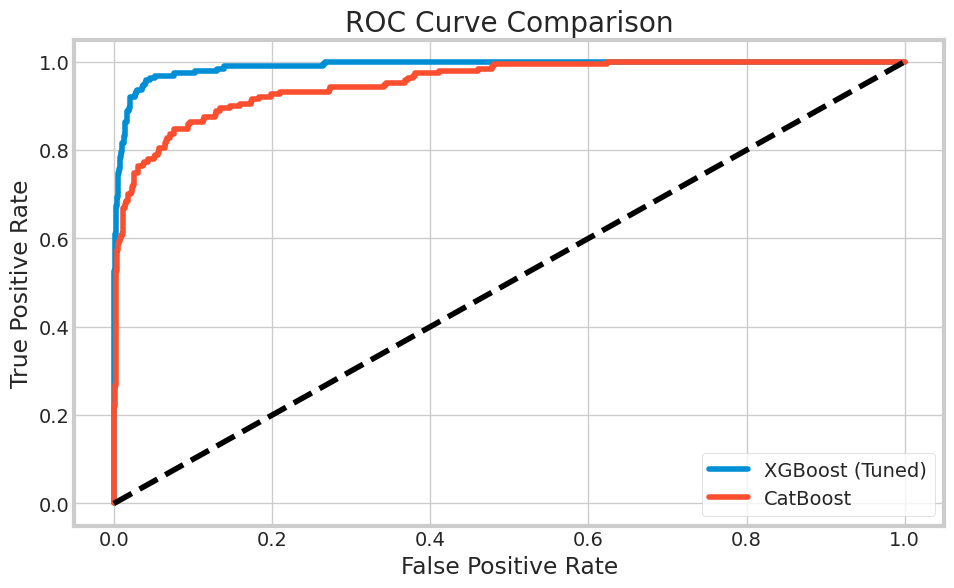

In [99]:
# ROC Curve
plt.figure(figsize=(10, 6))
plot_roc_curve(xgb_best, X_test_xgb, y_test, "XGBoost (Tuned)")
plot_roc_curve(catboost_baseline, X_test_cat, y_test, "CatBoost", is_catboost=True)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.plot([0, 1], [0, 1], "k--")
plt.legend()
plt.show()

In [100]:
# Metrics table
xgb_scores = compute_metrics(xgb_best, X_test_xgb, y_test)
catboost_scores = compute_metrics(catboost_baseline, X_test_cat, y_test, is_catboost=True)

scores_df = pd.DataFrame(
    [xgb_scores, catboost_scores],
    index=["XGBoost (Tuned)", "CatBoost"]
)

scores_df

,roc_auc,recall,precision,accuracy
XGBoost (Tuned),0.990,0.826,0.929,0.960
CatBoost,0.952,0.674,0.908,0.933


## **XGBoost is the Best Model**

In [101]:
# Classification report for tuned XGBoost
xgb_y_pred = xgb_best.predict(X_test_xgb)

print("XGBoost Classification Report")
print(classification_report(y_test, xgb_y_pred))

print("XGBoost Confusion Matrix")
print(confusion_matrix(y_test, xgb_y_pred))

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       936
           1       0.93      0.83      0.87       190

    accuracy                           0.96      1126
   macro avg       0.95      0.91      0.93      1126
weighted avg       0.96      0.96      0.96      1126

XGBoost Confusion Matrix
[[924  12]
 [ 33 157]]


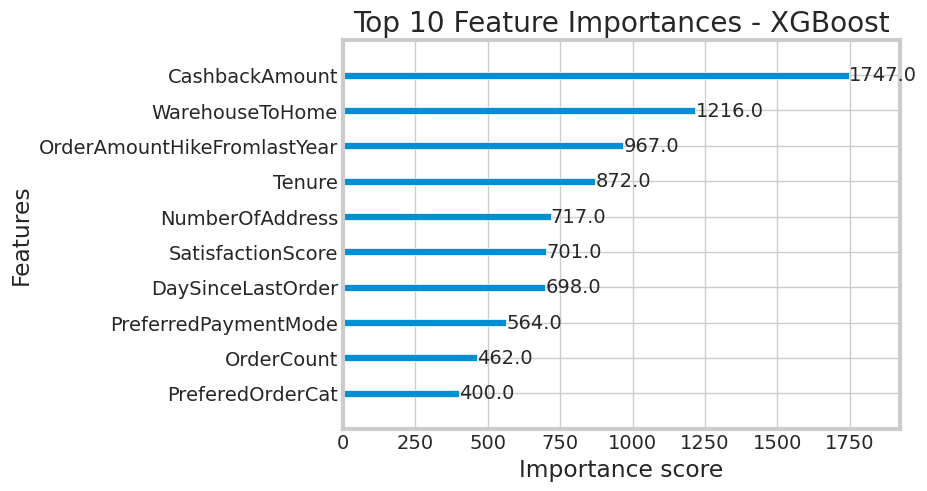

In [102]:
# Feature importance for tuned XGBoost
xgb.plot_importance(xgb_best, max_num_features=10)
plt.title("Top 10 Feature Importances - XGBoost")
plt.show()

### **SHAP Explainability for CatBoost**



/tmp/ipykernel_546/3073487692.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_cat)


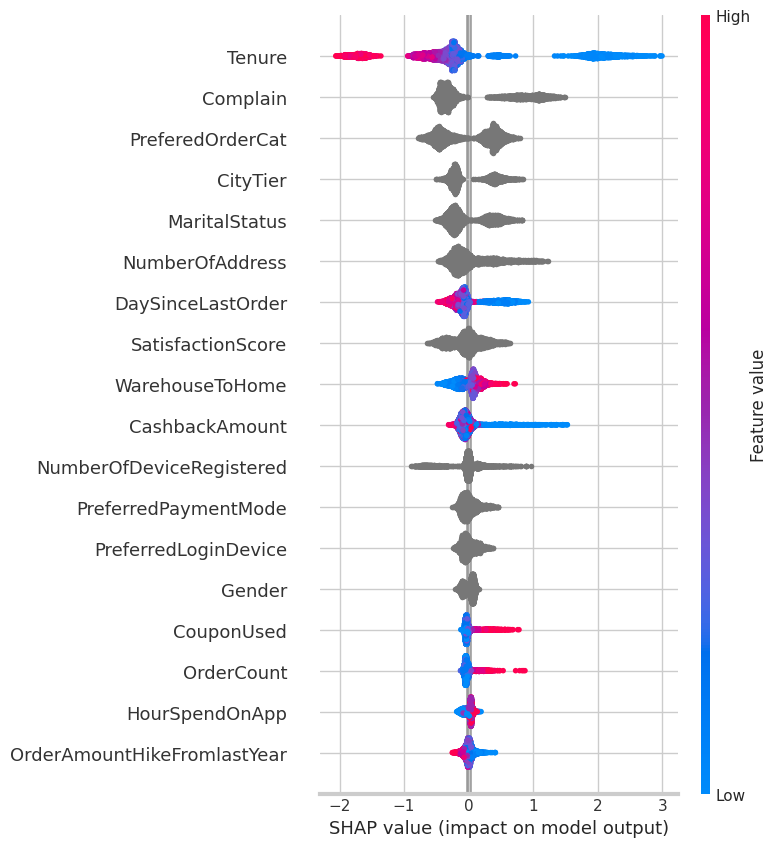

In [104]:
# SHAP EXPLAINABILITY
shap.initjs()

# SHAP for CatBoost
explainer = shap.TreeExplainer(catboost_baseline)
shap_values = explainer.shap_values(X_train_cat)

shap.summary_plot(shap_values, X_train_cat)

### **SHAP Explainability for XGBoost**



/tmp/ipykernel_546/690684726.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_xgb, X_train_xgb)


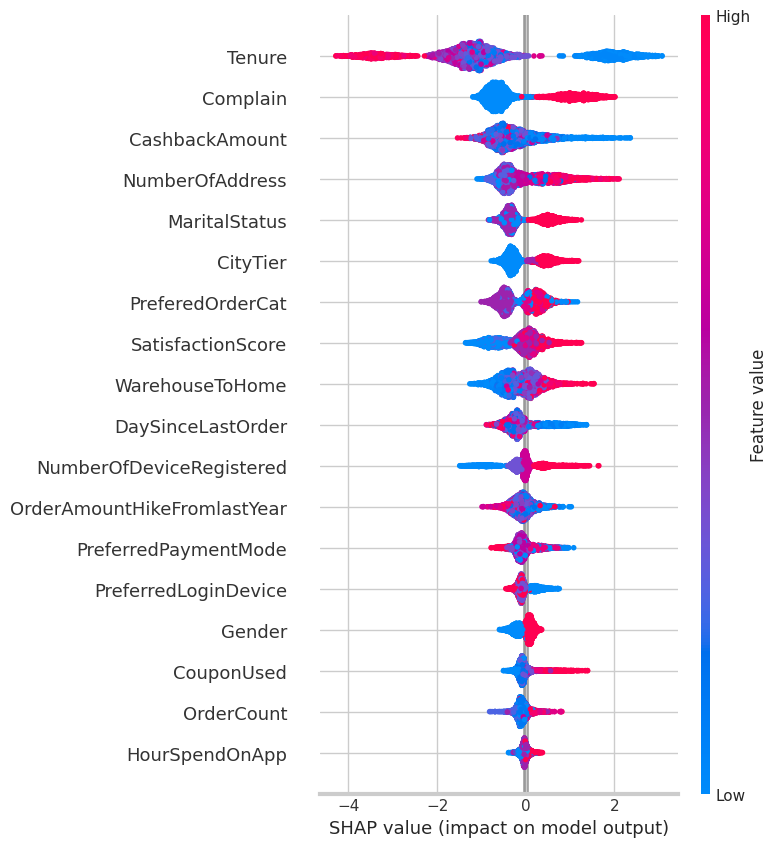

In [105]:
# SHAP for XGBoost
explainer_xgb = shap.TreeExplainer(xgb_best)
shap_values_xgb = explainer_xgb.shap_values(X_train_xgb)

shap.summary_plot(shap_values_xgb, X_train_xgb)

#***Prediction of High-Risk Churning Customers***

In [109]:
# 1. Selecting the Best Model ( Based on  evaluation metrics XGBoost is the best model)
final_churn_model = xgb_best
print(f"Selected model for predicting high-risk customers: {type(final_churn_model).__name__}")

# 2. Prepare the Data for Prediction
# Ensure all categorical columns in X_to_predict are of type 'category'
if 'categorical_cols' not in locals():
    categorical_cols = X.select_dtypes(include='object').columns.tolist()
X_to_predict = X.copy() # Make a copy to avoid modifying the original X
for col in set(categorical_cols).intersection(X_to_predict.columns):
    X_to_predict[col] = X_to_predict[col].astype("category")
print("\nInfo of X_to_predict :")
X_to_predict.info()

# Predict churn probabilities for all customers in X_to_predict
churn_probabilities = final_churn_model.predict_proba(X_to_predict)[:, 1]

Selected model for predicting high-risk customers: XGBClassifier

Info of X_to_predict :
<class 'pandas.core.frame.DataFrame'>
Index: 5626 entries, 0 to 5629
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Tenure                       5626 non-null   float64 
 1   PreferredLoginDevice         5626 non-null   category
 2   CityTier                     5626 non-null   category
 3   WarehouseToHome              5626 non-null   float64 
 4   PreferredPaymentMode         5626 non-null   category
 5   Gender                       5626 non-null   category
 6   HourSpendOnApp               5626 non-null   float64 
 7   NumberOfDeviceRegistered     5626 non-null   category
 8   PreferedOrderCat             5626 non-null   category
 9   SatisfactionScore            5626 non-null   category
 10  MaritalStatus                5626 non-null   category
 11  NumberOfAddress              5626 non

In [114]:
# Define "High-Risk" (Thresholding)
# starting with a common threshold of 0.5.
churn_risk_threshold = 0.50

# Create a binary flag for high-risk customers
is_high_risk_churn = (churn_probabilities >= churn_risk_threshold).astype(int)

# Generate a List of High-Risk Customers

# Use the CustomerID from the original df DataFrame, aligning indices with X
customer_ids_for_predictions = df.loc[X.index, 'CustomerID'].values

customer_churn_predictions = pd.DataFrame({
    'customerID': customer_ids_for_predictions,
    'Predicted_Churn_Probability': churn_probabilities,
    'Is_High_Risk_Churn': is_high_risk_churn,
    'Actual_Churn': y.values # Include actual churn for validation/reporting
})

# Sort by predicted probability to see the highest-risk customers first
customer_churn_predictions_sorted = customer_churn_predictions.sort_values(
    by='Predicted_Churn_Probability', ascending=False
).reset_index(drop=True)

print("\n--- Top 20 High-Risk Churn Customers ---")
print("\n**********************************************")
print(customer_churn_predictions_sorted.head(20))

# Get a count of high-risk customers
num_high_risk = customer_churn_predictions_sorted['Is_High_Risk_Churn'].sum()
print(f"\nTotal identified high-risk churn customers (probability >= {churn_risk_threshold}): {num_high_risk}")




--- Top 20 High-Risk Churn Customers ---

**********************************************
    customerID  Predicted_Churn_Probability  Is_High_Risk_Churn  Actual_Churn
0      52821.0                     0.998479                   1             1
1      54187.0                     0.998205                   1             1
2      54675.0                     0.997357                   1             1
3      53402.0                     0.997111                   1             1
4      54872.0                     0.997111                   1             1
5      50006.0                     0.997083                   1             1
6      51245.0                     0.996464                   1             1
7      53205.0                     0.996322                   1             1
8      53054.0                     0.996156                   1             1
9      53148.0                     0.995752                   1             1
10     51372.0                     0.995688         

#***Saving the High-Risk Customer List***

In [117]:
# Save the list of high-risk customers to a CSV file for the marketing team

high_risk_customer_list = customer_churn_predictions_sorted[
    customer_churn_predictions_sorted['Is_High_Risk_Churn'] == 1
].copy()
output_filename = "high_risk_churn_customers.csv"
high_risk_customer_list.to_csv(output_filename, index=False)

print(f"\nList of high-risk churn customers saved to: {output_filename}")
print(f"*Number of high-risk customers in the saved file: {len(high_risk_customer_list)}")

# Display a sample of the saved file's content
print("\nSample of the saved high_risk_churn_customers.csv:")
print(pd.read_csv(output_filename).head())



List of high-risk churn customers saved to: high_risk_churn_customers.csv
*Number of high-risk customers in the saved file: 996

Sample of the saved high_risk_churn_customers.csv:
   customerID  Predicted_Churn_Probability  Is_High_Risk_Churn  Actual_Churn
0     52821.0                     0.998479                   1             1
1     54187.0                     0.998205                   1             1
2     54675.0                     0.997357                   1             1
3     53402.0                     0.997111                   1             1
4     54872.0                     0.997111                   1             1
